# **MODELADO HÍBRIDO DEL MODELO MÍNIMO DE BERGMAN - ESCENARIO 1**

---

**Trabajo de Fin de Grado de Ingeniería del Software**

**Autora:** Laura Llorente Martínez

**Curso:** 2025 / 2026  

**Institución:** U-tad (Centro Universitario de Tecnología y Arte Digital)

> **Descripción:** Este *notebook* contiene el flujo de preprocesamiento, diseño, implementación, entrenamiento, validación y evaluación del modelo híbrido basado en las ecuaciones diferenciales ordinarias de Bergman y redes neuronales.

---

## 1. Librerías y configuración necesaria

Para la correcta ejecución del *notebook*, es necesario instalar los siguientes paquetes:

In [1]:
# %pip install tqdm pandas numpy seaborn matplotlib torch torchdiffeq scipy scikit-learn pykalman

In [2]:
import os
from pathlib import Path
from tqdm import tqdm
import copy

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchdiffeq import odeint

from scipy.integrate import ode
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import scipy.signal as signal
from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

from pykalman import KalmanFilter

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

Se establece una **paleta de colores** que se empleará para las distintas gráficas:

In [4]:
colors = {
    "adult": "#4C78A8",
    "adolescent": "#72B7B2",
    "child": "#54A24B",
    "black": "#111827",
    "blue": "#1F77B4",
    "purple": "#9467BD", 
    "red": "#D62728",
    "green": "#2CA02C",
    "yellow": "#FFBF00",
    "white": "#FFFFFF",
    "gray": "#E5E7EB"
}

## 2. Exploración de los datos

Para el trabajo se ha empleado un conjunto de datos del simulador `simglucose`, generado en el notebook: `DataSimulator.ipynb`

Cargamos uno de los CSV del conjunto de datos:

In [5]:
df = pd.read_csv("data/patients/adolescent#001.csv")

In [6]:
df.columns

Index(['Time', 'BG', 'CGM', 'CHO', 'insulin', 'LBGI', 'HBGI', 'Risk'], dtype='object')

Encontramos las siguientes variables:

- **`Time`:** frecuencia de muestreo.

- **`BG`:** concentración real de la glucosa en sangre del paciente, medida en mg/dL.

- **`CGM`:** glucosa medida por el sensor, expresada en mg/dL.

- **`CHO`:** carbohidratos ingeridos por el paciente en las comidas, medido en gramos.

- **`insulin`:** cantidad de insulina administrada por la bomba de infusión en ese instante, medida en unidades.

- **`LBGI`:** índice de riesgo de hipoglucemia del paciente.

- **`HBGI`:** índice de riesgo de hiperglucemia del paciente.

- **`Risk`:** índice de riesgo global, sumando LBGI y HBGI.

### 2.1. Exploración general

Verificamos el número de filas:

In [7]:
len(df)

3361

También, podemos analizar las dimensiones del Dataframe creado a partir del CSV. Podemos ver que este CSV cuenta con 3361 filas y 8 columnas.

In [8]:
df.shape

(3361, 8)

Analizamos las primeras y últimas filas del Dataframe:

In [9]:
df

,Time,BG,CGM,CHO,insulin,LBGI,HBGI,Risk
0,2026-02-24 07:00:00,149.020000,153.593538,0.0,0.013933,0.0,2.755276,2.755276
1,2026-02-24 07:03:00,149.020000,152.789386,0.0,0.013933,0.0,2.755276,2.755276
2,2026-02-24 07:06:00,149.020000,152.161938,0.0,0.013933,0.0,2.755276,2.755276
3,2026-02-24 07:09:00,149.020000,151.625381,0.0,0.013933,0.0,2.755276,2.755276
4,2026-02-24 07:12:00,149.020000,151.290235,0.0,0.013933,0.0,2.755276,2.755276
...,...,...,...,...,...,...,...,...
3356,2026-03-03 06:48:00,130.716746,120.398283,0.0,0.013933,0.0,0.782711,0.782711
3357,2026-03-03 06:51:00,131.315503,121.282810,0.0,0.013933,0.0,0.831223,0.831223
3358,2026-03-03 06:54:00,132.021287,122.479783,0.0,0.013933,0.0,0.889987,0.889987
3359,2026-03-03 06:57:00,132.836467,123.849941,0.0,0.013933,0.0,0.959951,0.959951


Las 10 primeras filas del CSV contienen los siguientes datos:

In [10]:
df.head(10)

,Time,BG,CGM,CHO,insulin,LBGI,HBGI,Risk
0,2026-02-24 07:00:00,149.020000,153.593538,0.0,0.013933,0.0,2.755276,2.755276
1,2026-02-24 07:03:00,149.020000,152.789386,0.0,0.013933,0.0,2.755276,2.755276
2,2026-02-24 07:06:00,149.020000,152.161938,0.0,0.013933,0.0,2.755276,2.755276
3,2026-02-24 07:09:00,149.020000,151.625381,0.0,0.013933,0.0,2.755276,2.755276
4,2026-02-24 07:12:00,149.020000,151.290235,0.0,0.013933,0.0,2.755276,2.755276
5,2026-02-24 07:15:00,149.020000,151.267020,0.0,0.013933,0.0,2.755276,2.755276
6,2026-02-24 07:18:00,149.020000,151.666254,0.0,0.013933,0.0,2.755276,2.755276
7,2026-02-24 07:21:00,149.020000,152.598456,0.0,0.013933,0.0,2.755276,2.755276
8,2026-02-24 07:24:00,149.020001,154.174147,0.0,0.013933,0.0,2.755276,2.755276
9,2026-02-24 07:27:00,149.020002,156.470768,0.0,0.013933,0.0,2.755276,2.755276


Las 10 últimas filas del CSV contienen los siguientes datos:

In [11]:
df.tail(10)

,Time,BG,CGM,CHO,insulin,LBGI,HBGI,Risk
3351,2026-03-03 06:33:00,128.765558,125.138131,0.0,0.013933,0.0,0.633390,0.633390
3352,2026-03-03 06:36:00,129.089790,122.554810,0.0,0.013933,0.0,0.657257,0.657257
3353,2026-03-03 06:39:00,129.425671,120.915458,0.0,0.013933,0.0,0.682383,0.682383
3354,2026-03-03 06:42:00,129.792505,120.091104,0.0,0.013933,0.0,0.710288,0.710288
3355,2026-03-03 06:45:00,130.214983,119.959139,0.0,0.013933,0.0,0.743020,0.743020
3356,2026-03-03 06:48:00,130.716746,120.398283,0.0,0.013933,0.0,0.782711,0.782711
3357,2026-03-03 06:51:00,131.315503,121.282810,0.0,0.013933,0.0,0.831223,0.831223
3358,2026-03-03 06:54:00,132.021287,122.479783,0.0,0.013933,0.0,0.889987,0.889987
3359,2026-03-03 06:57:00,132.836467,123.849941,0.0,0.013933,0.0,0.959951,0.959951
3360,2026-03-03 07:00:00,133.756603,125.255347,NaN,NaN,0.0,1.041568,1.041568


Podemos mostrar información sobre las columnas y el tipo de dato de cada una:

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3361 entries, 0 to 3360
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Time     3361 non-null   object 
 1   BG       3361 non-null   float64
 2   CGM      3361 non-null   float64
 3   CHO      3360 non-null   float64
 4   insulin  3360 non-null   float64
 5   LBGI     3361 non-null   float64
 6   HBGI     3361 non-null   float64
 7   Risk     3361 non-null   float64
dtypes: float64(7), object(1)
memory usage: 210.2+ KB


Para tratar con la fecha correctamente, convertimos la variable `time` a datetime:

In [13]:
df["Time"] = pd.to_datetime(df["Time"])
print(df["Time"].dtype)

datetime64[ns]


Comprobamos si hay algún valor faltante en las columnas:

In [14]:
print(df.isnull().sum())

Time       0
BG         0
CGM        0
CHO        1
insulin    1
LBGI       0
HBGI       0
Risk       0
dtype: int64


También podemos mostrar estadísticas de cada una de las columnas:

In [15]:
df.describe()

,BG,CGM,CHO,insulin,LBGI,HBGI,Risk
count,3361.000000,3361.000000,3360.000000,3360.000000,3361.000000,3361.000000,3.361000e+03
mean,115.927853,116.526344,0.148611,0.027066,0.348005,0.497566,8.455711e-01
std,17.868513,22.034129,1.813983,0.158409,0.685759,0.827887,8.995824e-01
min,81.793779,67.572500,0.000000,0.013933,0.000000,0.000000,5.628574e-08
25%,101.576697,100.608824,0.000000,0.013933,0.000000,0.000000,1.335069e-01
50%,114.899722,115.996249,0.000000,0.013933,0.000000,0.015252,5.020085e-01
75%,129.425671,132.019954,0.000000,0.013933,0.362751,0.682383,1.335976e+00
max,158.248141,192.545454,30.000000,2.513933,3.511679,4.063820,4.063820e+00


### 2.2. Exploración de variables

Calculamos la diferencia temporal entre dos observaciones consecutivas, para corroborar que efectivamente el intervalo temporal es de 3 minutos:

In [16]:
df["dt"] = df["Time"].diff()
df["dt"].value_counts().head()

0 days 00:03:00    3360
Name: dt, dtype: int64

Analizamos las ingestas diarias de la persona correspondiente al CSV explorado:

In [17]:
meal_events = df[df["CHO"] > 0]

meal_events[["Time", "CHO"]]

,Time,CHO
29,2026-02-24 08:27:00,17.000000
43,2026-02-24 09:09:00,6.000000
120,2026-02-24 13:00:00,28.666667
176,2026-02-24 15:48:00,4.666667
205,2026-02-24 17:15:00,25.000000
476,2026-02-25 06:48:00,13.333333
532,2026-02-25 09:36:00,2.666667
578,2026-02-25 11:54:00,21.000000
700,2026-02-25 18:00:00,25.000000
932,2026-02-26 05:36:00,15.333333


Podemos estudiar la cantidad media de ingestas del individuo al día:

In [18]:
# Añadimos una columna donde solo guardamos la parte de la fecha sin hora
meal_events["date"] = meal_events["Time"].dt.date  

C:\Users\Raul\AppData\Local\Temp/ipykernel_23180/608579185.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meal_events["date"] = meal_events["Time"].dt.date


In [19]:
# Agrupamos segun la columna date
meals_per_day = meal_events.groupby("date").size()

In [20]:
print("Número de ingestas al día")
meals_per_day

Número de ingestas al día


date
2026-02-24    5
2026-02-25    4
2026-02-26    3
2026-02-27    5
2026-02-28    4
2026-03-01    5
2026-03-02    5
2026-03-03    1
dtype: int64

In [21]:
meals_per_day.mean()

4.0

Es decir, el paciente tiene una media de aproximadamente 4 ingestas al día, que probablemente corresponden con desayuno, comida y cena, junto con algún almuerzo o merienda.

## 3. Preprocesamiento de los datos

Importamos CSVs con más información, generados con la simulación `simglucose`:

In [22]:
df_quest = pd.read_csv("data/Quest.csv")
df_params = pd.read_csv("data/vpatient_params.csv")

Analizamos la información contenida en el fichero `Quest.csv`:

In [23]:
df_quest.head()

,Name,CR,CF,Age,TDI
0,adolescent#001,12,15.036028,18,36.733915
1,adolescent#002,5,13.175089,19,62.031043
2,adolescent#003,23,33.525991,15,24.242780
3,adolescent#004,14,21.822484,17,35.252867
4,adolescent#005,12,20.908430,16,34.004721


In [24]:
df_quest.columns

Index(['Name', 'CR', 'CF', 'Age', 'TDI'], dtype='object')

In [25]:
df_quest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    30 non-null     object 
 1   CR      30 non-null     int64  
 2   CF      30 non-null     float64
 3   Age     30 non-null     int64  
 4   TDI     30 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 1.3+ KB


Analizamos la información contenida en el fichero `vpatient_params.csv`:

In [26]:
df_params.head()

,Name,i,x0_ 1,x0_ 2,x0_ 3,x0_ 4,x0_ 5,x0_ 6,x0_ 7,x0_ 8,...,kd,ksc,ka1,ka2,dosekempt,u2ss,isc1ss,isc2ss,kp1,patient_history
0,adolescent#001,1,0,0,0,250.621836,176.506560,4.697518,0,97.554,...,0.0185,0.0560,0.0025,0.0115,90000,1.216976,57.951224,93.225883,11.504823,0
1,adolescent#002,2,0,0,0,280.236267,30.954131,6.019305,0,119.180,...,0.0163,0.1314,0.0068,0.0269,90000,1.798300,77.848476,47.172125,4.196579,0
2,adolescent#003,3,0,0,0,326.553380,383.368339,3.487881,0,101.280,...,0.0149,0.1059,0.0030,0.0148,90000,1.446266,80.796984,81.342909,6.588789,0
3,adolescent#004,4,0,0,0,248.117090,214.758608,4.316765,0,108.880,...,0.0155,0.0751,0.0026,0.0121,90000,1.762633,97.383030,124.746857,6.041685,0
4,adolescent#005,5,0,0,0,279.047113,144.715759,5.162898,0,113.090,...,0.0151,0.0866,0.0032,0.0177,90000,1.534645,83.860398,71.541921,4.642232,0


In [27]:
df_params.columns

Index(['Name', 'i', 'x0_ 1', 'x0_ 2', 'x0_ 3', 'x0_ 4', 'x0_ 5', 'x0_ 6',
       'x0_ 7', 'x0_ 8', 'x0_ 9', 'x0_10', 'x0_11', 'x0_12', 'x0_13', 'BW',
       'EGPb', 'Gb', 'Ib', 'kabs', 'kmax', 'kmin', 'b', 'd', 'Vg', 'Vi', 'Ipb',
       'Vmx', 'Km0', 'k2', 'k1', 'p2u', 'm1', 'm5', 'CL', 'HEb', 'm2', 'm4',
       'm30', 'Ilb', 'ki', 'kp2', 'kp3', 'f', 'Gpb', 'ke1', 'ke2', 'Fsnc',
       'Gtb', 'Vm0', 'Rdb', 'PCRb', 'kd', 'ksc', 'ka1', 'ka2', 'dosekempt',
       'u2ss', 'isc1ss', 'isc2ss', 'kp1', 'patient_history'],
      dtype='object')

In [28]:
df_params.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 62 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             30 non-null     object 
 1   i                30 non-null     int64  
 2   x0_ 1            30 non-null     int64  
 3   x0_ 2            30 non-null     int64  
 4   x0_ 3            30 non-null     int64  
 5   x0_ 4            30 non-null     float64
 6   x0_ 5            30 non-null     float64
 7   x0_ 6            30 non-null     float64
 8   x0_ 7            30 non-null     int64  
 9   x0_ 8            30 non-null     float64
 10  x0_ 9            30 non-null     float64
 11  x0_10            30 non-null     float64
 12  x0_11            30 non-null     float64
 13  x0_12            30 non-null     float64
 14  x0_13            30 non-null     float64
 15  BW               30 non-null     float64
 16  EGPb             30 non-null     float64
 17  Gb               3

Lo primero que podemos hacer es añadir a cada Dataframe del dataset la información adicional de los pacientes que aparezca en estos CSVs, como la edad, el peso, etc. Todos estos metadatos pueden servir para la regularización posterior de la UDE.

In [29]:
def load_patient(file_path):
    # El ID de cada paciente sera el nombre del fichero CSV sin la extension
    file_name = os.path.basename(file_path)
    patient_id = file_name.split('.')[0]

    # Añadimos el ID del paciente al Dataframe
    df_patient = pd.read_csv(file_path)
    df_patient["patient_id"] = patient_id

    # Añadimos los metadatos del paciente al Dataframe
    patient_quest = df_quest[df_quest["Name"] == patient_id]
    patient_params = df_params[df_params["Name"] == patient_id]
    
    if not patient_quest.empty and not patient_params.empty:
        metadata = {
            "age_years": patient_quest["Age"].item(),
            "carb_ratio": patient_quest["CR"].item(),
            "correction_factor": patient_quest["CF"].item(),
            "tdi": patient_quest["TDI"].item(),
            
            "weight_kg": patient_params["BW"].item(),
            "basal_glucose": patient_params["Gb"].item(),
            "basal_insulin": patient_params["Ib"].item(),
            "kabs": patient_params["kabs"].item(),
            "vmx": patient_params["Vmx"].item(),
            "u2ss": patient_params["u2ss"].item(),
            "vg": patient_params["Vg"].item(),
            "vi": patient_params["Vi"].item(),
            "kmax": patient_params["kmax"].item(),
            "kmin": patient_params["kmin"].item(),
            "b": patient_params["b"].item(),
            "d": patient_params["d"].item()
        }
        for key, value in metadata.items():
            df_patient[key] = value

    else:
        print(f"No se encontraron metadatos para el paciente {patient_id}")

    return df_patient

Ahora, para mayor facilidad de acceso, juntamos los CSV de todos los pacientes en un mismo Dataframe:

In [30]:
# Ubicacion de los CSV de todos los pacientes
data_path = Path("data/patients")

In [31]:
all_patients = []

In [32]:
for file in data_path.rglob("*.csv"):
    # Ignoramos los ficheros checkpoint que se generan en jupyter notebooks
    if file.name.endswith("checkpoint.csv"):
        continue
        
    df_patient = load_patient(file)
    all_patients.append(df_patient)

In [33]:
# Creamos un Dataframe juntando cada Dataframe de los pacientes

df_patients = pd.concat(all_patients, ignore_index = True)

In [34]:
print("Pacientes cargados: ", df_patients["patient_id"].nunique())

Pacientes cargados:  30


Inspeccionamos el nuevo Dataframe global:

In [35]:
df_patients.head()

,Time,BG,CGM,CHO,insulin,LBGI,HBGI,Risk,patient_id,age_years,...,basal_insulin,kabs,vmx,u2ss,vg,vi,kmax,kmin,b,d
0,2026-02-24 07:00:00,149.02,153.593538,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,97.554,0.091043,0.074667,1.216976,1.6818,0.048153,0.015865,0.008334,0.83072,0.32294
1,2026-02-24 07:03:00,149.02,152.789386,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,97.554,0.091043,0.074667,1.216976,1.6818,0.048153,0.015865,0.008334,0.83072,0.32294
2,2026-02-24 07:06:00,149.02,152.161938,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,97.554,0.091043,0.074667,1.216976,1.6818,0.048153,0.015865,0.008334,0.83072,0.32294
3,2026-02-24 07:09:00,149.02,151.625381,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,97.554,0.091043,0.074667,1.216976,1.6818,0.048153,0.015865,0.008334,0.83072,0.32294
4,2026-02-24 07:12:00,149.02,151.290235,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,97.554,0.091043,0.074667,1.216976,1.6818,0.048153,0.015865,0.008334,0.83072,0.32294


In [36]:
# Convertimos Time a formato fecha
df_patients["Time"] = pd.to_datetime(df_patients["Time"], errors = "coerce")

In [37]:
df_patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100830 entries, 0 to 100829
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Time               100830 non-null  datetime64[ns]
 1   BG                 100830 non-null  float64       
 2   CGM                100830 non-null  float64       
 3   CHO                100800 non-null  float64       
 4   insulin            100800 non-null  float64       
 5   LBGI               100830 non-null  float64       
 6   HBGI               100830 non-null  float64       
 7   Risk               100830 non-null  float64       
 8   patient_id         100830 non-null  object        
 9   age_years          100830 non-null  int64         
 10  carb_ratio         100830 non-null  int64         
 11  correction_factor  100830 non-null  float64       
 12  tdi                100830 non-null  float64       
 13  weight_kg          100830 non-null  float64 

Volvemos a comprobar ahora la posible existencia de valores nulos:

In [38]:
print(df_patients.isnull().sum())

Time                  0
BG                    0
CGM                   0
CHO                  30
insulin              30
LBGI                  0
HBGI                  0
Risk                  0
patient_id            0
age_years             0
carb_ratio            0
correction_factor     0
tdi                   0
weight_kg             0
basal_glucose         0
basal_insulin         0
kabs                  0
vmx                   0
u2ss                  0
vg                    0
vi                    0
kmax                  0
kmin                  0
b                     0
d                     0
dtype: int64


Al final de todos los CSV, en la última medición, `CHO` e `insulin` son nulos. Como hay $30$ pacientes, encontramos $30$ valores nulos para estas variables.

Los rellenamos con valores *default*, teniendo en cuenta la coherencia clínica y metabólica del contexto:

In [39]:
df_patients["CHO"] = df_patients["CHO"].fillna(0.0)
df_patients["insulin"] = df_patients["insulin"].fillna(df_patients["insulin"].min())

In [40]:
print(df_patients.isnull().sum())

Time                 0
BG                   0
CGM                  0
CHO                  0
insulin              0
LBGI                 0
HBGI                 0
Risk                 0
patient_id           0
age_years            0
carb_ratio           0
correction_factor    0
tdi                  0
weight_kg            0
basal_glucose        0
basal_insulin        0
kabs                 0
vmx                  0
u2ss                 0
vg                   0
vi                   0
kmax                 0
kmin                 0
b                    0
d                    0
dtype: int64


In [41]:
df_patients.columns

Index(['Time', 'BG', 'CGM', 'CHO', 'insulin', 'LBGI', 'HBGI', 'Risk',
       'patient_id', 'age_years', 'carb_ratio', 'correction_factor', 'tdi',
       'weight_kg', 'basal_glucose', 'basal_insulin', 'kabs', 'vmx', 'u2ss',
       'vg', 'vi', 'kmax', 'kmin', 'b', 'd'],
      dtype='object')

## 4. Gráficas

### 4.1. Gráficas de contexto general

Podemos analizar cómo varía la glucosa en sangre a lo largo del tiempo:

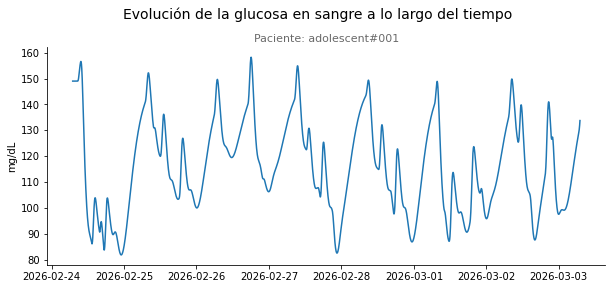

In [42]:
plt.figure(figsize = (10,4))
plt.plot(df["Time"], df["BG"], color = colors["blue"])

plt.suptitle("Evolución de la glucosa en sangre a lo largo del tiempo", fontsize = 14, y = 1.02)
plt.title("Paciente: adolescent#001", fontsize = 11, color = "dimgray")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.ylabel("mg/dL")
plt.show()

A continuación, se analiza si la media global de la glucosa en sangre de todos los pacientes presenta los incrementos esperados durante las horas correspondientes a las ingestas principales (desayuno, comida y cena):

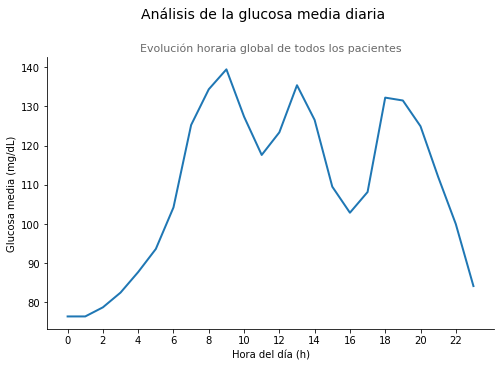

In [43]:
# Obtenemos solo las horas y agrupamos la glucosa de cada paciente por esas horas
df_patients["hour"] = df_patients["Time"].dt.hour
patients_glucose = df_patients.groupby("hour")["BG"]

# Calculamos la media de glucosa de todos los pacientes por horas
mean_glucose = patients_glucose.mean()

plt.figure(figsize=(8,5))
plt.plot(mean_glucose.index, mean_glucose.values, color = colors["blue"], linewidth = 2)
plt.suptitle("Análisis de la glucosa media diaria", fontsize = 14, y = 1.02)
plt.title("Evolución horaria global de todos los pacientes", fontsize = 11, color = "dimgray")

plt.xlabel("Hora del día (h)")
plt.ylabel("Glucosa media (mg/dL)")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(range(0, 24, 2))
plt.show()

Podemos observar tres incrementos claro: el primero alrededor de las $9$ (correspondiente al desayuno), el segundo alrededor de las $13$ (correspondiente a la comida) y el tercero alrededor de las $19-20$ (correspondiente a la cena).

Ahora, representamos cómo varía la glucosa medida por el sensor CGM a lo largo del tiempo: 

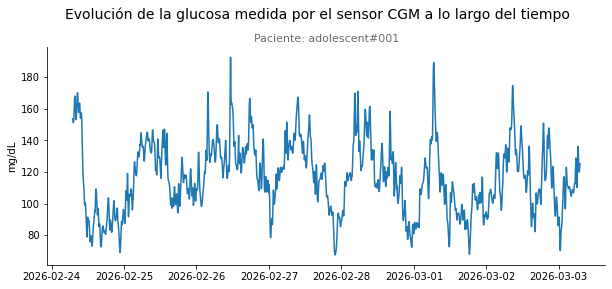

In [44]:
plt.figure(figsize = (10,4))
plt.plot(df["Time"], df["CGM"], color = colors["blue"])

plt.suptitle("Evolución de la glucosa medida por el sensor CGM a lo largo del tiempo", fontsize = 14, y = 1.02)
plt.title("Paciente: adolescent#001", fontsize = 11, color = "dimgray")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.ylabel("mg/dL")
plt.show()

### 4.2. Eliminación del ruido de los datos - Filtro de Kalman

Realizamos una limpieza del **ruido de la glucosa asociado a la señal CGM**, empleando el **filtro de Kalman**:

In [45]:
# Matriz de transicion -> modelo de velocidad constante
transition_matrix = np.array([
    [1, 3.0],   # dt = 3.0
    [0, 1]
])

In [46]:
# Matriz de observacion -> tenemos datos de glucosa pero no de velocidad
observation_matrix = np.array([[1, 0]])

In [47]:
# Ruido del proceso -> en una situacion realista, el cuerpo humano es lento procesando los cambios
process_covariance = np.array([
    [0.001, 0],
    [0, 0.001]
])

In [48]:
# Ruido de medida -> lo que se suele equivocar el sensor
observation_covariance = np.array([[100]])

In [49]:
# Estado inicial

initial_state = np.array([df["CGM"][0], 0])    # empezamos en el primer valor de la glucosa y con velocidad 0

initial_covariance = np.array([
    [1000, 0],     # existe mucha incertidumbre al comienzo
    [0, 100]
])

In [50]:
# Instanciamos el filtro de Kalman

kf = KalmanFilter(transition_matrices = transition_matrix,
                  observation_matrices = observation_matrix,
                  initial_state_mean = initial_state,
                  initial_state_covariance = initial_covariance,
                  observation_covariance = observation_covariance,
                  transition_covariance = process_covariance)

In [51]:
# El filtro devuelve medias y covarianzas
means, covariances = kf.filter(df["CGM"])

In [52]:
# De las medias, nos quedamos solo con la primera columna, que es la glucosa limpia 
# La segunda columna es la velocidad
clean_glucose = means[:, 0]

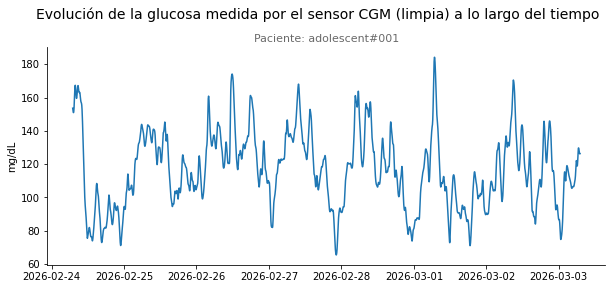

In [53]:
plt.figure(figsize = (10,4))
plt.plot(df["Time"], clean_glucose, color = colors["blue"])

plt.suptitle("Evolución de la glucosa medida por el sensor CGM (limpia) a lo largo del tiempo", fontsize = 14, y = 1.02)
plt.title("Paciente: adolescent#001", fontsize = 11, color = "dimgray")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.ylabel("mg/dL")
plt.show()

Es decir, se ha conseguido limpiar el ruido de la glucosa. Por lo tanto, ahora hay que aplicarlo al dataset completo:

In [54]:
# Establecemos como valor generico inicial de la glucosa 100 mg/dL
initial_state = np.array([100, 0])

In [55]:
# Instanciamos el filtro de Kalman

kf = KalmanFilter(transition_matrices = transition_matrix,
                  observation_matrices = observation_matrix,
                  initial_state_mean = initial_state,
                  initial_state_covariance = initial_covariance,
                  observation_covariance = observation_covariance,
                  transition_covariance = process_covariance)

In [56]:
# Aplicamos el filtro paciente a paciente y sobreescribimos la columna de glucosa medida por el sensor

df_patients["CGM"] = df_patients.groupby("patient_id")["CGM"].transform(
    lambda x: kf.filter(x.values)[0][:, 0]
)

Ahora, elegimos a un paciente para demostrar la comparativa entre la glucosa medida por el sensor CGM original y la que se obtiene después de aplicar el filtro de Kalman:

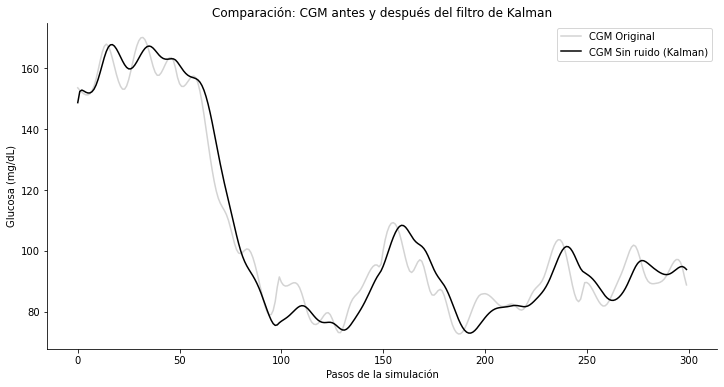

In [57]:
# Analisis para el primer adolescente del conjunto de datos
df_original = pd.read_csv("data/patients/adolescent#001.csv")
df_denoised = df_patients[df_patients["patient_id"] == "adolescent#001"]

plt.figure(figsize = (12, 6))
plt.plot(df_original.index[:300], df_original["CGM"][:300], color = "lightgray", label = "CGM Original")
plt.plot(df_denoised.index[:300], df_denoised["CGM"][:300], color = "black", label = "CGM Sin ruido (Kalman)")

plt.title("Comparación: CGM antes y después del filtro de Kalman")
plt.xlabel("Pasos de la simulación")
plt.ylabel("Glucosa (mg/dL)")

# Quitamos las lineas superior y derecha del plot
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend()
plt.show()

También se puede comprobar la diferencia entre la glucosa medida con el sensor (con y sin ruido) y la glucosa en sangre del paciente:

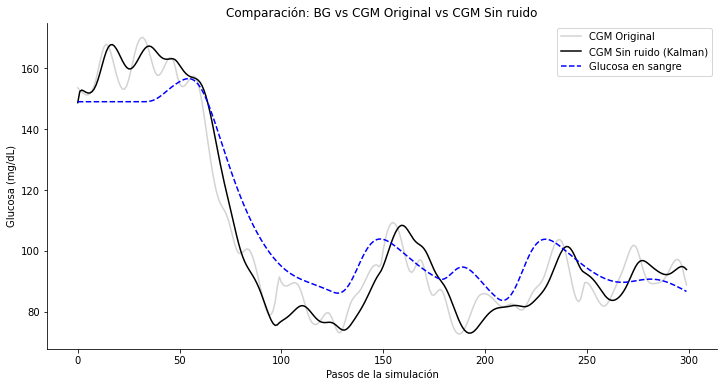

In [58]:
# Analisis para el primer adolescente del conjunto de datos
df_original = pd.read_csv("data/patients/adolescent#001.csv")
df_denoised = df_patients[df_patients["patient_id"] == "adolescent#001"]

plt.figure(figsize = (12, 6))
plt.plot(df_original.index[:300], df_original["CGM"][:300], color = "lightgray", label = "CGM Original")
plt.plot(df_denoised.index[:300], df_denoised["CGM"][:300], color = "black", label = "CGM Sin ruido (Kalman)")
plt.plot(df_original.index[:300], df_original["BG"][:300], color = "blue", linestyle = "--", label = "Glucosa en sangre")

plt.title("Comparación: BG vs CGM Original vs CGM Sin ruido")
plt.xlabel("Pasos de la simulación")
plt.ylabel("Glucosa (mg/dL)")

# Quitamos las lineas superior y derecha del plot
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend()
plt.show()

## 5. Configuración paramétrica del sistema

### 5.1. Parámetros del modelo

Se desarrolla una función que implementa las ecuaciones diferenciales ordinarias que **modelan el vaciado gástrico y la absorción intestinal de carbohidratos**. Está basada en un modelo multicompartimental, y calcula cómo los alimentos ingeridos se trasladan desde el estómago (fases sólida y líquida) hacia el intestino (donde son absorbidos).

In [59]:
def digestive_system_model(t, x, last_Qsto, last_foodtaken, p_dict):
    # Inicializaciones
    dxdt = np.zeros(3)
    qsto = x[0] + x[1]
    Dbar = last_Qsto + last_foodtaken * 1000.0
    
    # Extraemos las variables necesarias para los calculos
    kmin = p_dict["kmin"]
    kmax = p_dict["kmax"]
    b = p_dict["b"]
    d_param = p_dict["d"]
    k_abs = p_dict["kabs"]

    # Formulas para calcular la tasa de vaciado gastrico
    if Dbar > 0:
        aa = 5.0 / (2.0 * Dbar * max(1.0 - b, 1e-6))
        cc = 5.0 / (2.0 * Dbar * max(d_param, 1e-6))
        kgut = kmin + (kmax - kmin) / 2.0 * (
            np.tanh(aa * (qsto - b * Dbar)) - np.tanh(cc * (qsto - d_param * Dbar)) + 2.0
        )
    else:
        kgut = kmax

    # EDOs que modelan el vaciado gastrico y la absorcion intestinal
    dxdt[0] = -kmax * x[0]
    dxdt[1] = kmax * x[0] - kgut * x[1]
    dxdt[2] = kgut * x[1] - k_abs * x[2]
    
    return dxdt

A continuación, se desarrolla una función que simula el proceso de digestión a lo largo del tiempo para calcular la **tasa de aparición de glucosa** ($R_a$) en sangre.

In [60]:
def calculate_glucose_appearance(parameters, cho_array, dt = 3.0):
    p_dict = parameters.to_dict()

    # Establecemos los valores fisiologicos necesarios para el calculo de la tasa de aparicion de la glucosa
    f = 0.9
    k_abs = p_dict["kabs"]
    weight = p_dict["weight_kg"]
    vol_dist_glucose = p_dict["vg"]

    # Elegimos el solver lsoda
    # Es recomendable para sistemas que necesitan un cambio automatico entre ecuaciones rigidas y no rigidas
    solver = ode(digestive_system_model).set_integrator("lsoda")
    solver.set_initial_value([0.0, 0.0, 0.0], 0.0)

    # Variables de seguimiento de estado
    Ra_list = []
    last_Qsto = 0.0
    last_foodtaken = 0.0
    is_eating = False
    prev_cho = 0.0

    for cho in cho_array:
        
        # Simulacion del impacto de las ingestas
        if cho > 0:
            # Si hay ingesta, sumamos los carbohidratos al compartimento de estomago solido
            new_state = solver.y
            new_state[0] += cho * 1000.0    # pasamos de g a mg
            solver.set_initial_value(new_state, solver.t)

            # Si se acaba de empezar a comer
            if prev_cho <= 0:
                last_Qsto = solver.y[0] + solver.y[1]
                last_foodtaken = 0.0
                is_eating = True

        # Acumulamos la comida mientras dure el evento de ingesta
        if is_eating:
            last_foodtaken += cho

        if cho <= 0 and prev_cho > 0:
            is_eating = False

        # Pasamos los parametros de la digestion a las EDOs
        solver.set_f_params(last_Qsto, last_foodtaken, p_dict)
        
        if solver.successful():
            solver.integrate(solver.t + dt)

        # Evitamos que la masa pueda ser negativa, por fisiologia
        if np.any(solver.y < 0):
            solver.set_initial_value(np.maximum(solver.y, 0), solver.t)

        # Calculo de la tasa de aparicion
        Qgut = max(0, solver.y[2])
        Ra = (f * k_abs * Qgut) / (weight * vol_dist_glucose)
        Ra_list.append(Ra)
        
        prev_cho = cho
        
    return np.array(Ra_list)

Por último, se desarrolla una función para la **preparación de los datos para el modelo**. 

A partir del Dataframe global, aisla la información de un paciente en específico y extrae las variables importantes. Además, fija constantes fisiológicas, reconstruye la señal de insulina exógena y obtiene la señal de la entrada de la glucosa. 

Devuelve todas las series temporales y parámetros necesarios para el modelo.

In [61]:
def patient_variables(df, patient_id):
    # Elegimos a un solo paciente
    df_patient = df[df["patient_id"] == patient_id].copy()
    
    BW = df_patient["weight_kg"].iloc[0]
    
    # CONSTANTES
    # Fijamos p_1, p_2 y n segun los valores tipicos de la literatura
    p1 = 0.015    # min^-1
    p2 = 0.025    # min^-1
    n = 0.0926    # min^-1

    
    # TIEMPO
    # Necesitamos el tiempo en minutos
    t = (df_patient["Time"] - df_patient["Time"].iloc[0]).dt.total_seconds().to_numpy() / 60.0

    
    # GLUCOSA OBSERVADA
    # Medida en mg/dL
    G_obs = df_patient["CGM"].to_numpy()

    
    # INSULINA EXOGENA ADMINISTRADA 
    # Medida en U/min

    # Volumen de distribución de insulina
    vi_per_kg = df_patient["vi"]  # L / kg
    V_I = vi_per_kg * BW     # L
    
    u_I_abs = df_patient["insulin"].to_numpy() * 1000.0 / V_I  # mU/L/min
    
    u2ss = df_patient["u2ss"]
    basal_Umin = u2ss * BW / 6000.0
    u_I_basal = basal_Umin * 1000.0 / V_I  # mU/L/min
    
    # Aislamiento del bolo
    u_I_bolus = u_I_abs - u_I_basal

    # Una inyeccion de insulina no entra a la sangre de golpe, tarda un tiempo
    # Creamos un filtro exponencial decreciente que simula la absorcion a lo largo de 60 pasos
    bolus_filter = np.exp(-np.linspace(0, 3, 60))   # 180 / 3
    bolus_filter /= bolus_filter.sum()

    # Aplicamos el filtro al bolo mediante convolucion
    u_I_bolus_filtered = np.convolve(u_I_bolus, bolus_filter, mode = "full")[:len(u_I_bolus)]
    u_I = u_I_bolus_filtered
    u_I = np.maximum(u_I, 0.0)

    
    # APARICION GLUCOSA    
    # Carbohidratos en kg
    carbs_kg = df_patient["CHO"].to_numpy()
    
    # u_G representa la aparicion de glucosa en sangre (absorbida por los nutrientes)
    u_G = calculate_glucose_appearance(parameters = df_patient.iloc[0], cho_array = carbs_kg, dt = 3.0)

    # GLUCOSA BASAL E INSULINA BASAL
    Gb = df_patient["basal_glucose"].iloc[0]
    Ib = df_patient["basal_insulin"].iloc[0] / 6.0

    return t, G_obs, u_I, u_G, Gb, Ib, p1, p2, n

Mostramos un ejemplo de los valores que devuelve la función para un paciente:

In [62]:
patient_id = "adolescent#001"
t, G_obs, u_I, u_G, Gb, Ib, p1, p2, n = patient_variables(df_patients, patient_id)

print("t:", t[:10])
print("G_obs:", G_obs[:10])
print("u_I:", u_I[:10])
print("u_G:", u_G[:10])
print("Gb:", Gb)
print("Ib:", Ib)
print("p1:", p1)
print("p2:", p2)
print("n:", n)

t: [ 0.  3.  6.  9. 12. 15. 18. 21. 24. 27.]
G_obs: [148.72139843 152.41648714 152.86529384 152.53598952 152.13694513
 151.89160754 151.92057455 152.31597368 153.16063851 154.52280124]
u_I: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
u_G: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Gb: 149.02
Ib: 16.259
p1: 0.015
p2: 0.025
n: 0.0926


Añadimos los valores nuevos necesarios al dataset global para cada paciente:

In [63]:
for patient in df_patients["patient_id"].unique():

    # Obtenemos las variables del paciente especifico
    t, G_obs, u_I, u_G, Gb, Ib, p1, p2, n = patient_variables(df_patients, patient)
    location = (df_patients["patient_id"] == patient)

    # Añadimos las necesarias como nuevas columnas al dataframe
    df_patients.loc[location, "t_min"] = t
    df_patients.loc[location, "u_I"] = u_I
    df_patients.loc[location, "u_G"] = u_G
    df_patients.loc[location, "Gb"] = Gb
    df_patients.loc[location, "Ib"] = Ib

Inspeccionamos el nuevo conjunto de datos:

In [64]:
df_patients.columns

Index(['Time', 'BG', 'CGM', 'CHO', 'insulin', 'LBGI', 'HBGI', 'Risk',
       'patient_id', 'age_years', 'carb_ratio', 'correction_factor', 'tdi',
       'weight_kg', 'basal_glucose', 'basal_insulin', 'kabs', 'vmx', 'u2ss',
       'vg', 'vi', 'kmax', 'kmin', 'b', 'd', 'hour', 't_min', 'u_I', 'u_G',
       'Gb', 'Ib'],
      dtype='object')

In [65]:
df_patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100830 entries, 0 to 100829
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Time               100830 non-null  datetime64[ns]
 1   BG                 100830 non-null  float64       
 2   CGM                100830 non-null  float64       
 3   CHO                100830 non-null  float64       
 4   insulin            100830 non-null  float64       
 5   LBGI               100830 non-null  float64       
 6   HBGI               100830 non-null  float64       
 7   Risk               100830 non-null  float64       
 8   patient_id         100830 non-null  object        
 9   age_years          100830 non-null  int64         
 10  carb_ratio         100830 non-null  int64         
 11  correction_factor  100830 non-null  float64       
 12  tdi                100830 non-null  float64       
 13  weight_kg          100830 non-null  float64 

In [66]:
print(df_patients.isnull().sum())

Time                 0
BG                   0
CGM                  0
CHO                  0
insulin              0
LBGI                 0
HBGI                 0
Risk                 0
patient_id           0
age_years            0
carb_ratio           0
correction_factor    0
tdi                  0
weight_kg            0
basal_glucose        0
basal_insulin        0
kabs                 0
vmx                  0
u2ss                 0
vg                   0
vi                   0
kmax                 0
kmin                 0
b                    0
d                    0
hour                 0
t_min                0
u_I                  0
u_G                  0
Gb                   0
Ib                   0
dtype: int64


In [67]:
df_patients.head()

,Time,BG,CGM,CHO,insulin,LBGI,HBGI,Risk,patient_id,age_years,...,kmax,kmin,b,d,hour,t_min,u_I,u_G,Gb,Ib
0,2026-02-24 07:00:00,149.02,148.721398,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.83072,0.32294,7,0.0,0.0,0.0,149.02,16.259
1,2026-02-24 07:03:00,149.02,152.416487,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.83072,0.32294,7,3.0,0.0,0.0,149.02,16.259
2,2026-02-24 07:06:00,149.02,152.865294,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.83072,0.32294,7,6.0,0.0,0.0,149.02,16.259
3,2026-02-24 07:09:00,149.02,152.535990,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.83072,0.32294,7,9.0,0.0,0.0,149.02,16.259
4,2026-02-24 07:12:00,149.02,152.136945,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.83072,0.32294,7,12.0,0.0,0.0,149.02,16.259


In [68]:
df_patients

,Time,BG,CGM,CHO,insulin,LBGI,HBGI,Risk,patient_id,age_years,...,kmax,kmin,b,d,hour,t_min,u_I,u_G,Gb,Ib
0,2026-02-24 07:00:00,149.020000,148.721398,0.0,0.013933,0.000000,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.830720,0.322940,7,0.0,0.000000,0.000000,149.020000,16.259000
1,2026-02-24 07:03:00,149.020000,152.416487,0.0,0.013933,0.000000,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.830720,0.322940,7,3.0,0.000000,0.000000,149.020000,16.259000
2,2026-02-24 07:06:00,149.020000,152.865294,0.0,0.013933,0.000000,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.830720,0.322940,7,6.0,0.000000,0.000000,149.020000,16.259000
3,2026-02-24 07:09:00,149.020000,152.535990,0.0,0.013933,0.000000,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.830720,0.322940,7,9.0,0.000000,0.000000,149.020000,16.259000
4,2026-02-24 07:12:00,149.020000,152.136945,0.0,0.013933,0.000000,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.830720,0.322940,7,12.0,0.000000,0.000000,149.020000,16.259000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100825,2026-03-03 06:48:00,101.138968,89.094964,0.0,0.006625,0.393996,0.000000,0.393996,child#010,12,...,0.036428,0.019218,0.678361,0.097284,6,10068.0,16.813367,1.932192,136.415177,17.549088
100826,2026-03-03 06:51:00,108.651942,90.611386,0.0,0.006625,0.042416,0.000000,0.042416,child#010,12,...,0.036428,0.019218,0.678361,0.097284,6,10071.0,15.979812,2.053307,136.415177,17.549088
100827,2026-03-03 06:54:00,118.013288,93.177003,0.0,0.006625,0.000000,0.079053,0.079053,child#010,12,...,0.036428,0.019218,0.678361,0.097284,6,10074.0,15.187582,2.143752,136.415177,17.549088
100828,2026-03-03 06:57:00,128.927390,96.937849,0.0,0.006625,0.000000,0.645255,0.645255,child#010,12,...,0.036428,0.019218,0.678361,0.097284,6,10077.0,14.434628,2.207764,136.415177,17.549088


In [69]:
df_patients.T

,0,1,2,3,4,5,6,7,8,9,...,100820,100821,100822,100823,100824,100825,100826,100827,100828,100829
Time,2026-02-24 07:00:00,2026-02-24 07:03:00,2026-02-24 07:06:00,2026-02-24 07:09:00,2026-02-24 07:12:00,2026-02-24 07:15:00,2026-02-24 07:18:00,2026-02-24 07:21:00,2026-02-24 07:24:00,2026-02-24 07:27:00,...,2026-03-03 06:33:00,2026-03-03 06:36:00,2026-03-03 06:39:00,2026-03-03 06:42:00,2026-03-03 06:45:00,2026-03-03 06:48:00,2026-03-03 06:51:00,2026-03-03 06:54:00,2026-03-03 06:57:00,2026-03-03 07:00:00
BG,149.02,149.02,149.02,149.02,149.02,149.02,149.02,149.02,149.020001,149.020002,...,87.882499,88.59288,89.775818,91.933953,95.600895,101.138968,108.651942,118.013288,128.92739,140.987
CGM,148.721398,152.416487,152.865294,152.53599,152.136945,151.891608,151.920575,152.315974,153.160639,154.522801,...,88.813258,88.74645,88.504439,88.308355,88.413846,89.094964,90.611386,93.177003,96.937849,101.960418
CHO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
insulin,0.013933,0.013933,0.013933,0.013933,0.013933,0.013933,0.013933,0.013933,0.013933,0.013933,...,0.006625,0.006625,0.006625,0.006625,0.006625,0.006625,0.006625,0.006625,0.006625,0.004817
LBGI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.11123,1.976195,1.763408,1.412498,0.919206,0.393996,0.042416,0.0,0.0,0.0
HBGI,2.755276,2.755276,2.755276,2.755276,2.755276,2.755276,2.755276,2.755276,2.755276,2.755276,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.079053,0.645255,1.773973
Risk,2.755276,2.755276,2.755276,2.755276,2.755276,2.755276,2.755276,2.755276,2.755276,2.755276,...,2.11123,1.976195,1.763408,1.412498,0.919206,0.393996,0.042416,0.079053,0.645255,1.773973
patient_id,adolescent#001,adolescent#001,adolescent#001,adolescent#001,adolescent#001,adolescent#001,adolescent#001,adolescent#001,adolescent#001,adolescent#001,...,child#010,child#010,child#010,child#010,child#010,child#010,child#010,child#010,child#010,child#010
age_years,18,18,18,18,18,18,18,18,18,18,...,12,12,12,12,12,12,12,12,12,12


Podemos realizar un **análisis metabólico** de un paciente en concreto:

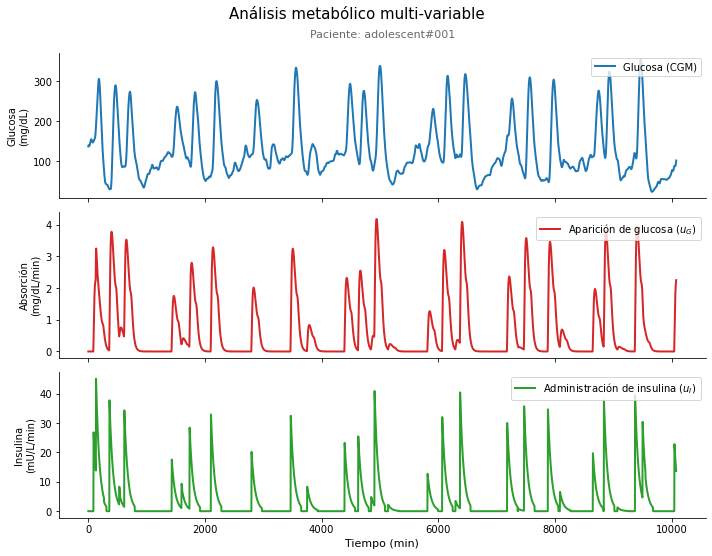

In [70]:
fig, ax = plt.subplots(3, 1, figsize = (10, 8), sharex = True)

plt.suptitle("Análisis metabólico multi-variable", fontsize = 15, y = 0.96)
ax[0].set_title(f"Paciente: {patient_id}", fontsize = 11, color = "dimgray", pad = 15)

# Grafica 1: glucosa medida por el sensor
ax[0].plot(t, G_obs, label = "Glucosa (CGM)", color = colors["blue"], linewidth = 2)
ax[0].set_ylabel("Glucosa\n(mg/dL)")

# Grafica 2: tasa de aparicion (u_G)
ax[1].plot(t, u_G, label = "Aparición de glucosa ($u_G$)", color = colors["red"], linewidth = 2)
ax[1].set_ylabel("Absorción\n(mg/dL/min)")

# Grafica 3: insulina administrada (u_I)
ax[2].plot(t, u_I, label = "Administración de insulina ($u_I$)", color = colors["green"], linewidth = 2)
ax[2].set_ylabel("Insulina\n(mU/L/min)")
ax[2].set_xlabel("Tiempo (min)", fontsize = 11)

for i in range(3):
    # Ocultamos bordes superior y derecho
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].legend(frameon = True, loc = "upper right")

plt.tight_layout()
plt.subplots_adjust(top = 0.88)
plt.show()

El perfil metabólico multivariable del paciente `adolescent#001` ilustra la dinámica fisiológica de causa-efecto propia de la diabetes tipo $1$. 

Como se observa en la gráfica, las ingestas de carbohidratos se traducen en picos de absorción continua ($u_G$) que provocan situaciones de hiperglucemia visibles en la señal del sensor CGM (azul). En respuesta a estas subidas, la administración de bolos de insulina ($u_I$) logra contrarrestar el incremento de glucosa y estabilizar los niveles sistémicos a lo largo del tiempo. 

También podemos graficar la **correlación** entre los carbohidratos, la aparición de glucosa en sangre ($u_G$) y la insulina absorbida ($u_I$), para analizar la respuesta de insulina del paciente frente a la absorción de las comidas:

,CHO (Comida),Aparición glucosa (u_G),Bolo absorbido (u_I)
CHO (Comida),1.000000,-0.030262,-0.039691
Aparición glucosa (u_G),-0.030262,1.000000,0.778107
Bolo absorbido (u_I),-0.039691,0.778107,1.000000


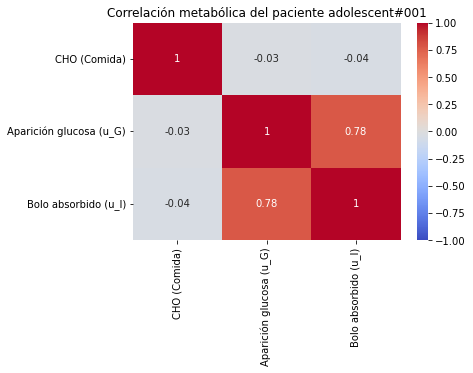

In [71]:
# Aislamos la columna CHO original del paciente
original_CHO = df_patients[df_patients["patient_id"] == patient_id]["CHO"].to_numpy()

# Señales a correlacionar
df_analysis = pd.DataFrame({
    "CHO (Comida)": original_CHO,
    "Aparición glucosa (u_G)": u_G,
    "Bolo absorbido (u_I)": u_I
})

# Calculamos la matriz de correlación
correlation = df_analysis.corr()

display(correlation)
plt.figure(figsize = (6, 4))
sns.heatmap(correlation, annot = True, cmap = "coolwarm", vmin = -1, vmax = 1)
plt.title(f"Correlación metabólica del paciente {patient_id}")
plt.show()

Se puede observar la relación fisiológica subyacente (0.78) entre las señales $u_G$ y $u_I$. Esta correlación lineal es moderadamente alta, incluso teniendo en cuenta los retardos de absorción, la variabilidad metabólica y las no-linealidades del cuerpo humano.

Esto justifica el empleo de **Ecuaciones Diferenciales Universales** para capturar dinámicas temporales no lineales y estados ocultos, que no se pueden capturar con absoluta precisión con correlaciones directas como esta.

### 5.2. Elección del parámetro a modelar

En el modelado del sistema glucosa-insulina mediante el Modelo Mínimo de Bergman, siempre se supone que los parámetros metabólicos son constantes en el tiempo. 

Entre ellos, el parámetro $p_3$ (que representa la capacidad de la insulina para incrementar la eliminación de glucosa) resulta crítico, ya que determina la sensibilidad temporal del paciente a los bolos administrados.

En la realidad clínica de los pacientes con diabetes tipo $1$, la sensibilidad a la insulina fluctúa debido a diferentes factores. El siguiente conjunto de funciones tiene como objetivo demostrar esta variabilidad temporal, es decir, que el parámetro $p_3$ no es constante en el tiempo.

**Función que resuelve las EDOs del modelo de Bergman para una ventana de tiempo**

In [72]:
def simulate_bergman_window(t, u_I, u_G, Gb, Ib, p1, p2, n, p3, G0):
    # Interpolacion continua
    # Los solvers de EDOs necesitan evaluar la entrada en cualquier instante, no solo en los pasos discretos
    uI_fun = interp1d(t, u_I, kind = "linear", fill_value = "extrapolate")
    uG_fun = interp1d(t, u_G, kind = "linear", fill_value = "extrapolate")

    # Definicion del sistema de EDOs de Bergman
    def ode_function(ti, y):
        G, X, I = y
        dGdt = -p1 * (G - Gb) - X * G + float(uG_fun(ti))
        dXdt = -p2 * X + p3 * (I - Ib)
        dIdt = -n * (I - Ib) + float(uI_fun(ti))
        return [dGdt, dXdt, dIdt]

    # Resolvemos el sistema desde t[0] hasta t[-1]
    solution = solve_ivp(ode_function, (t[0], t[-1]), [G0, 0.0, Ib], t_eval = t, method = "LSODA")

    # Devolvemos la glucosa predicha
    return solution.y[0]

**Función que prueba valores de $p_3$ para decidir cuál consigue una mejor simulación de la glucosa predicha respecto a la curva de glucosa real**

In [ ]:
def fit_p3_per_event(df, patient_id, window_minutes = 120, dt_minutes = 3.0, p3_grid = None):
    # Variables del paciente
    t_all, G_obs, u_I, u_G, Gb, Ib, p1, p2, n = patient_variables(df, patient_id)

    # Pasamos las 2 horas a pasos de tiempo discretos
    horizon = int(window_minutes / dt_minutes)

    if p3_grid is None:
        p3_grid = np.logspace(-6, -3, 100)

    # Buscamos en la señal de insulina momentos donde se inyecto un bolo
    events, _ = signal.find_peaks(u_I, height = 1.0, distance = horizon)
    results = []

    # Iteramos sobre cada evento de inyeccion detectado
    for k, idx in enumerate(events):
        end_idx = idx + horizon
        if end_idx >= len(t_all): continue

        # Aislamos los datos de esas 2 horas
        t_window = t_all[idx:end_idx + 1] - t_all[idx]
        G_window = G_obs[idx:end_idx + 1]
        uI_window = u_I[idx:end_idx + 1]
        uG_window = u_G[idx:end_idx + 1]

        best_p3_local = p3_grid[0]
        min_rmse = float('inf')

        # Probamos cada posible valor de p3 para ver cual predice mejor la glucosa
        for p3_candidate in p3_grid:
            try:
                # Simulamos la ventana con el p3 actual
                G_prediction = simulate_bergman_window(
                    t = t_window, u_I = uI_window, u_G = uG_window, Gb = Gb, Ib = Ib,
                    p1 = p1, p2 = p2, n = n, p3 = p3_candidate, G0 = G_window[0]
                )
                
                # Evaluamos el error entre la glucosa real (G_window) y la predicha (G_prediction)
                rmse = np.sqrt(np.mean((G_window - G_prediction) ** 2))

                # Nos quedamos con el p3 que minimice el error
                if rmse < min_rmse:
                    min_rmse = rmse
                    best_p3_local = p3_candidate
            except:
                continue

        # Guardamos el mejor resultado
        results.append({
            "event": k,
            "best_p3": best_p3_local,
            "rmse": min_rmse
        })

    return pd.DataFrame(results)

**Función para visualizar el análisis anterior**

In [74]:
def plot_p3_per_event(df, patient_id, window_minutes = 120, dt_minutes = 3.0, p3_grid = None):
    # Obtenemos los p3 optimos por evento
    result_df = fit_p3_per_event(
        df = df, patient_id = patient_id, window_minutes = window_minutes, 
        dt_minutes = dt_minutes, p3_grid = p3_grid)

    if result_df.empty:
        print("No se encontraron eventos válidos.")
        return result_df

    # Grafico
    plt.figure(figsize = (10, 5))
    plt.scatter(result_df["event"], result_df["best_p3"])
    plt.plot(result_df["event"], result_df["best_p3"], alpha = 0.6)

    # Quitamos las lineas superior y derecha del plot
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.suptitle("$p_3$ óptimo local por evento", fontsize = 16)
    plt.title(f"Paciente: {patient_id}", fontsize = 12, color = "dimgray")
    plt.xlabel("Evento de bolo")
    plt.ylabel("$p_3$ óptimo")
    plt.show()

    return result_df

Comprobamos con el paciente `adolescent#001` que el parámetro $p_3$ no es constante a lo largo del tiempo:

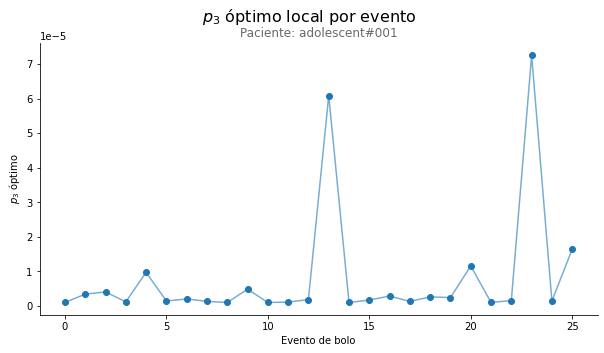

In [75]:
result_df = plot_p3_per_event(
    df = df_patients,
    patient_id = "adolescent#001",
    window_minutes = 120,
    dt_minutes = 3.0,
    p3_grid = np.logspace(-6, -3, 80)
)

## 6. División del conjunto de datos

Primero, tenemos que ver cuántos pacientes tenemos:

In [76]:
print(df_patients["patient_id"].nunique())

30


In [77]:
patient_ids = df_patients["patient_id"].unique()

Usamos **$20$ para train, $5$ para test y $5$ para validation**, siguiendo aproximadamente la división común de $70\%$ para entrenamiento, $15\%$ para validación y $15\%$ para test:

In [78]:
# Aseguramos que haya la misma proporcion de tipos de pacientes (adulto, adolescente, niño) en cada subconjunto
age_groups = [pid.split("#")[0] for pid in patient_ids]

In [79]:
train_ids, testval_ids = train_test_split(patient_ids, test_size = 10, random_state = 42, stratify = age_groups)

In [80]:
age_groups_testval = [pid.split("#")[0] for pid in testval_ids]

In [81]:
test_ids, val_ids = train_test_split(testval_ids, test_size = 5, random_state = 42, stratify = age_groups_testval)

In [82]:
print(f"Division de los datos -> Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

Division de los datos -> Train: 20 | Val: 5 | Test: 5


Separamos en los Dataframes correspondientes:

In [83]:
df_train = df_patients[df_patients["patient_id"].isin(train_ids)].copy()
df_test = df_patients[df_patients["patient_id"].isin(test_ids)].copy()
df_val = df_patients[df_patients["patient_id"].isin(val_ids)].copy()

Inspeccionamos cada Dataframe:

In [84]:
df_train.shape

(67220, 31)

In [85]:
df_train.columns

Index(['Time', 'BG', 'CGM', 'CHO', 'insulin', 'LBGI', 'HBGI', 'Risk',
       'patient_id', 'age_years', 'carb_ratio', 'correction_factor', 'tdi',
       'weight_kg', 'basal_glucose', 'basal_insulin', 'kabs', 'vmx', 'u2ss',
       'vg', 'vi', 'kmax', 'kmin', 'b', 'd', 'hour', 't_min', 'u_I', 'u_G',
       'Gb', 'Ib'],
      dtype='object')

In [86]:
df_train.head()

,Time,BG,CGM,CHO,insulin,LBGI,HBGI,Risk,patient_id,age_years,...,kmax,kmin,b,d,hour,t_min,u_I,u_G,Gb,Ib
0,2026-02-24 07:00:00,149.02,148.721398,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.83072,0.32294,7,0.0,0.0,0.0,149.02,16.259
1,2026-02-24 07:03:00,149.02,152.416487,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.83072,0.32294,7,3.0,0.0,0.0,149.02,16.259
2,2026-02-24 07:06:00,149.02,152.865294,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.83072,0.32294,7,6.0,0.0,0.0,149.02,16.259
3,2026-02-24 07:09:00,149.02,152.535990,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.83072,0.32294,7,9.0,0.0,0.0,149.02,16.259
4,2026-02-24 07:12:00,149.02,152.136945,0.0,0.013933,0.0,2.755276,2.755276,adolescent#001,18,...,0.015865,0.008334,0.83072,0.32294,7,12.0,0.0,0.0,149.02,16.259


In [87]:
df_test.shape

(16805, 31)

In [88]:
df_val.shape

(16805, 31)

Analizamos la **distribución demográfica por subconjunto** con una gráfica:

In [89]:
# Funcion para contar cuantos hay de cada grupo

def count_groups(ids):
    groups = [pid.split("#")[0] for pid in ids]
    
    return {
        "adult": groups.count("adult"),
        "adolescent": groups.count("adolescent"),
        "child": groups.count("child")
    }

In [90]:
# Contamos los pacientes de cada subconjunto usando los ids

counts_train = count_groups(train_ids)
counts_val = count_groups(val_ids)
counts_test = count_groups(test_ids)

In [91]:
# Funcion para añadir el valor numerico de pacientes encima de cada barra

def top_label(bars):
    for bar in bars:
        # Altura de la barra
        height = bar.get_height()
        
        if height > 0:
            ax.annotate(f'{height}', xy = (bar.get_x() + bar.get_width() / 2, height), xytext = (0, 3),
                        textcoords = "offset points", ha = "center", va = "bottom", fontsize = 11, weight = "bold")

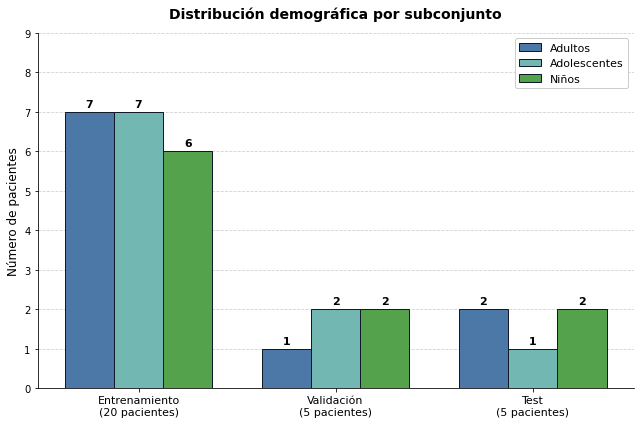

In [92]:
categories = ["Entrenamiento\n(20 pacientes)", "Validación\n(5 pacientes)", "Test\n(5 pacientes)"]

# Numero de pacientes por grupo de edad (adultos, adolescentes, niños) y por subconjunto (train, val, test)
adults = [counts_train["adult"], counts_val["adult"], counts_test["adult"]]
adolescents = [counts_train["adolescent"], counts_val["adolescent"], counts_test["adolescent"]]
children = [counts_train["child"], counts_val["child"], counts_test["child"]]

# Grafico
x = np.arange(len(categories))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 6))

# Dibujamos 3 barras por cada grupo
bar_adult = ax.bar(x - width, adults, width, label = "Adultos", color = colors["adult"], edgecolor = colors["black"])
bar_adolescent = ax.bar(x, adolescents, width, label = "Adolescentes", color = colors["adolescent"], edgecolor = colors["black"])
bar_child = ax.bar(x + width, children, width, label = "Niños", color = colors["child"], edgecolor = colors["black"])

ax.set_ylabel("Número de pacientes", fontsize = 12)
ax.set_title("Distribución demográfica por subconjunto", fontsize = 14, pad = 15, fontweight = "bold")
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize = 11)
ax.legend(fontsize = 11, framealpha = 1)

# Añadimos el numero encima de cada barra
top_label(bar_adult)
top_label(bar_adolescent)
top_label(bar_child)

# Quitamos las lineas superior y derecha del plot
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

max_val = max(adults + adolescents + children)
ax.set_ylim(0, max_val + 2)
ax.grid(axis = "y", linestyle = "--", alpha = 0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 7. Normalización

La normalización se realiza en aquellas variables que se van a introducir en la red neuronal.

Gracias al **percentil $99$**, se puede asegurar que el $99\%$ de las veces los datos van a escalar al rango $[0, 1]$, pero con la ventaja de que si existe algún *outlier*, pueda tomar valores por encima de $1$
sin afectar al resto de los datos. Esto es una característica clave para que la red neuronal aprenda
correctamente, teniendo en cuenta también eventos extraordinarios.

In [93]:
percentile = 0.99

In [94]:
scales = {
    "u_I": df_train["u_I"].quantile(percentile),
    "u_G": df_train["u_G"].quantile(percentile),
    "weight_kg": df_train["weight_kg"].quantile(percentile),
    "age_years": df_train["age_years"].quantile(percentile),
    "tdi": df_train["tdi"].quantile(percentile),
    "carb_ratio": df_train["carb_ratio"].quantile(percentile),
    "correction_factor": df_train["correction_factor"].quantile(percentile),
    "Gb": df_train["Gb"].quantile(percentile),
    "Ib": df_train["Ib"].quantile(percentile)
}

In [95]:
for k, v in scales.items():
    print(f"{k}: {v:.2f}")

u_I: 53.82
u_G: 3.04
weight_kg: 111.10
age_years: 68.00
tdi: 68.32
carb_ratio: 25.00
correction_factor: 42.65
Gb: 152.41
Ib: 23.01


La primera transformación realizada es la correspondiente a la **glucosa continua del sensor CGM**, que se normaliza respecto a la glucosa basal del paciente ($G_b$).

Esta decisión se debe a que la glucosa basal representa el estado fisiológico en reposo del paciente sin perturbaciones, que es una referencia mucho más robusta que el valor inicial de la medición (el cual podría coincidir con un valor extremo puntual de glucosa no representativo) o la media (que es muy sensible a las ingestas a lo largo del día).

In [96]:
def apply_transform(df, scales):
    df_transform = df.copy()

    # Aplicamos una transformacion especial para la glucosa, que escala mejor en base a su valor basal
    df_transform["G_obs_norm"] = df_transform["CGM"] / df_transform["basal_glucose"]

    # Para el resto de variables, normalizamos con el percentil
    df_transform["u_G_norm"] = df_transform["u_G"] / scales["u_G"]
    df_transform["u_I_norm"] = df_transform["u_I"] / scales["u_I"]
    df_transform["age_norm"] = df_transform["age_years"] / scales["age_years"]
    df_transform["weight_norm"] = df_transform["weight_kg"] / scales["weight_kg"]
    df_transform["TDI_norm"] = df_transform["tdi"] / scales["tdi"]
    df_transform["CR_norm"] = df_transform["carb_ratio"] / scales["carb_ratio"]
    df_transform["CF_norm"] = df_transform["correction_factor"] / scales["correction_factor"]
    df_transform["Gb_norm"] = df_transform["Gb"] / scales["Gb"]
    df_transform["Ib_norm"] = df_transform["Ib"] / scales["Ib"]

    return df_transform

Ahora hacemos el transform en los tres subconjuntos, porque se debe realizar el mismo preprocesamiento en todos los datos disponibles:

In [97]:
df_train_norm = apply_transform(df_train, scales)
df_test_norm = apply_transform(df_test, scales)
df_val_norm = apply_transform(df_val, scales)

In [98]:
df_train_norm.columns

Index(['Time', 'BG', 'CGM', 'CHO', 'insulin', 'LBGI', 'HBGI', 'Risk',
       'patient_id', 'age_years', 'carb_ratio', 'correction_factor', 'tdi',
       'weight_kg', 'basal_glucose', 'basal_insulin', 'kabs', 'vmx', 'u2ss',
       'vg', 'vi', 'kmax', 'kmin', 'b', 'd', 'hour', 't_min', 'u_I', 'u_G',
       'Gb', 'Ib', 'G_obs_norm', 'u_G_norm', 'u_I_norm', 'age_norm',
       'weight_norm', 'TDI_norm', 'CR_norm', 'CF_norm', 'Gb_norm', 'Ib_norm'],
      dtype='object')

In [99]:
df_train_norm.iloc[:,-10:]

,G_obs_norm,u_G_norm,u_I_norm,age_norm,weight_norm,TDI_norm,CR_norm,CF_norm,Gb_norm,Ib_norm
0,0.997996,0.000000,0.000000,0.264706,0.618416,0.537706,0.48,0.352517,0.977757,0.706708
1,1.022792,0.000000,0.000000,0.264706,0.618416,0.537706,0.48,0.352517,0.977757,0.706708
2,1.025804,0.000000,0.000000,0.264706,0.618416,0.537706,0.48,0.352517,0.977757,0.706708
3,1.023594,0.000000,0.000000,0.264706,0.618416,0.537706,0.48,0.352517,0.977757,0.706708
4,1.020916,0.000000,0.000000,0.264706,0.618416,0.537706,0.48,0.352517,0.977757,0.706708
...,...,...,...,...,...,...,...,...,...,...
100825,0.653116,0.636481,0.312377,0.176471,0.316949,0.302297,0.72,0.685122,0.895054,0.762783
100826,0.664232,0.676378,0.296890,0.176471,0.316949,0.302297,0.72,0.685122,0.895054,0.762783
100827,0.683040,0.706171,0.282171,0.176471,0.316949,0.302297,0.72,0.685122,0.895054,0.762783
100828,0.710609,0.727257,0.268182,0.176471,0.316949,0.302297,0.72,0.685122,0.895054,0.762783


In [100]:
df_test_norm.shape

(16805, 41)

In [101]:
df_val_norm.shape

(16805, 41)

## 8. Tensores y ventanas temporales

Establecemos los tensores de los parametros del modelo. Son necesarios porque permiten actualizar pesos cuando se realiza *backpropagation*.

Creamos los **tensores de Torch**, usando la funcion `torch.tensor()`. Gracias a esto, se crea una nueva copia del array de numpy, y los cambios en el tensor no se reflejarán en el array y viceversa.

Adicionalmente, para conseguir un correcto aprendizaje de la red neuronal, es conveniente pasar la información continua del paciente en fragmentos de longitud fija y más reducida. Para realizar esto, se aplica una técnica de data augmentation conocida como *sliding windows*.

Otra razón para emplear esta solución es que la integración de modelos sobre series temporales largas provoca eventualmente inestabilidad en la retropropagación. Esto se debe a que se acumulan los errores, dando lugar a una explosión de gradientes o a un desvanecimiento de gradientes. Por lo tanto, como el conjunto de datos abarca $7$ días completos, es necesario realizar esta **división en ventanas**.

El primer parámetro imprescindible para su funcionamiento es el tamaño de la ventana (`window_size`). Se ha fijado en $200$ pasos temporales, que equivalen a $10$ horas por ventana, teniendo en cuenta la frecuencia de muestreo de $3$ minutos.

Vamos a crear un nuevo dataset con toda esta información unificada:

In [102]:
class BergmanDataset(Dataset):
    def __init__(self, df_norm, window_size = 200, stride = 170):
        self.df_norm = df_norm
        self.window_size = window_size
        self.stride = stride
        
        # Todas las variables que se han normalizado
        self.static_vars = ["age_norm", "weight_norm", "TDI_norm", "CR_norm", "CF_norm", "Gb_norm", "Ib_norm"]
        self.dynamic_vars = ["G_obs_norm", "u_I_norm", "u_G_norm"]

        self.windows = []
        self.patient_ids = df_norm["patient_id"].unique()

        print(f"Procesando {len(self.patient_ids)} pacientes desde el DataFrame normalizado.")

        # Iteramos paciente por paciente para no mezclar series temporales
        for patient in self.patient_ids:
            patient_data = df_norm[df_norm["patient_id"] == patient].copy()

            # Obtenemos las variables no normalizadas para las EDOs
            t, G_obs, u_I, u_G, Gb, Ib, p1, p2, n = patient_variables(df_patients, patient)

            total_steps = len(patient_data)

            # Separamos las mediciones del paciente en ventanas de tamaño fijo usando el stride
            for start_idx in range(0, total_steps - self.window_size, self.stride):
                end_idx = start_idx + self.window_size
                chunk = patient_data.iloc[start_idx:end_idx]
                
                # Tiempo en minutos (0, 3, 6...)
                t_values = np.arange(0, self.window_size * 3, 3)

                # Extraemos y convertimos a tensores de flotantes, necesario para PyTorch
                dyn_data = chunk[self.dynamic_vars].values.astype(np.float32)

                # Almacenamos toda la informacion de esta ventana en un diccionario
                self.windows.append({
                    "patient_id": patient,
                    "t": torch.tensor(t_values, dtype=torch.float32),
                    
                    # ESTADO INICIAL
                    # y0 = [G_norm inicial, X inicial (0.0), I_norm inicial (1.0)]
                    "y0": torch.tensor([dyn_data[0, 0], 0.0, 1.0], dtype = torch.float32),
                    
                    # VARIABLES SIN NORMALIZAR -> para las EDOs de Bergman
                    "u_I_phys": torch.tensor(chunk["u_I"].values, dtype = torch.float32),
                    "u_G_phys": torch.tensor(chunk["u_G"].values, dtype = torch.float32),
                    
                    "Gb": torch.tensor(chunk["Gb"].iloc[0], dtype=torch.float32),
                    "Ib": torch.tensor(chunk["Ib"].iloc[0], dtype=torch.float32),

                    "p1": torch.tensor(p1, dtype = torch.float32),
                    "p2": torch.tensor(p2, dtype = torch.float32),
                    "n":  torch.tensor(n, dtype = torch.float32),

                    # VARIABLES NORMALIZADAS -> para la red neuronal
                    "u_I": torch.tensor(dyn_data[:, 1], dtype = torch.float32),
                    "u_G": torch.tensor(dyn_data[:, 2], dtype = torch.float32),
                    "static": torch.tensor(chunk[self.static_vars].iloc[0].values.astype(np.float32), dtype = torch.float32), 

                    # PARA COMPARAR PREDICCION DEL MODELO CON CURVA REAL DE GLUCOSA
                    "target": torch.tensor(dyn_data[:, 0], dtype = torch.float32),
                })
                
    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        return self.windows[idx]

Creamos el dataset correspondiente para cada subconjunto de datos:

In [103]:
train_dataset = BergmanDataset(df_train_norm, stride = 10)

Procesando 20 pacientes desde el DataFrame normalizado.


In [104]:
test_dataset = BergmanDataset(df_test_norm)

Procesando 5 pacientes desde el DataFrame normalizado.


In [105]:
val_dataset = BergmanDataset(df_val_norm)

Procesando 5 pacientes desde el DataFrame normalizado.


Para el conjunto de entrenamiento, se ha elegido un `stride` más pequeño, para generar más
cantidad de ventanas solapadas y mejorar el aprendizaje del modelo. Sin embargo, para los conjuntos
de validación y *test*, se ha escogido un `stride` mayor, con la finalidad de evaluar el rendimiento del
modelo sobre ventanas temporales más independientes.

## 9. DataLoaders

Una vez creados los tensores para los tres subconjuntos de datos, se gestionan mediante DataLoaders, para separar cada `BergmanDataset` en lotes que mejoran el rendimiento.

In [106]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)

In [107]:
first_patient = next(iter(train_loader))

for key, value in first_patient.items():
    if torch.is_tensor(value):
        print(f"{key:20} | Shape: {str(value.shape):22} | Data type: {value.dtype}")

t                    | Shape: torch.Size([32, 200])  | Data type: torch.float32
y0                   | Shape: torch.Size([32, 3])    | Data type: torch.float32
u_I_phys             | Shape: torch.Size([32, 200])  | Data type: torch.float32
u_G_phys             | Shape: torch.Size([32, 200])  | Data type: torch.float32
Gb                   | Shape: torch.Size([32])       | Data type: torch.float32
Ib                   | Shape: torch.Size([32])       | Data type: torch.float32
p1                   | Shape: torch.Size([32])       | Data type: torch.float32
p2                   | Shape: torch.Size([32])       | Data type: torch.float32
n                    | Shape: torch.Size([32])       | Data type: torch.float32
u_I                  | Shape: torch.Size([32, 200])  | Data type: torch.float32
u_G                  | Shape: torch.Size([32, 200])  | Data type: torch.float32
static               | Shape: torch.Size([32, 7])    | Data type: torch.float32
target               | Shape: torch.Size

Para los DataLoaders de validación y test, **no se aplica aleatoriedad de las muestras**, preservando el orden original para obtener una reconstrucción correcta de la señal.

In [108]:
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [109]:
first_patient = next(iter(test_loader))

for key, value in first_patient.items():
    if torch.is_tensor(value):
        print(f"{key:20} | Shape: {str(value.shape):22} | Data type: {value.dtype}")

t                    | Shape: torch.Size([32, 200])  | Data type: torch.float32
y0                   | Shape: torch.Size([32, 3])    | Data type: torch.float32
u_I_phys             | Shape: torch.Size([32, 200])  | Data type: torch.float32
u_G_phys             | Shape: torch.Size([32, 200])  | Data type: torch.float32
Gb                   | Shape: torch.Size([32])       | Data type: torch.float32
Ib                   | Shape: torch.Size([32])       | Data type: torch.float32
p1                   | Shape: torch.Size([32])       | Data type: torch.float32
p2                   | Shape: torch.Size([32])       | Data type: torch.float32
n                    | Shape: torch.Size([32])       | Data type: torch.float32
u_I                  | Shape: torch.Size([32, 200])  | Data type: torch.float32
u_G                  | Shape: torch.Size([32, 200])  | Data type: torch.float32
static               | Shape: torch.Size([32, 7])    | Data type: torch.float32
target               | Shape: torch.Size

In [110]:
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)

In [111]:
first_patient = next(iter(val_loader))

for key, value in first_patient.items():
    if torch.is_tensor(value):
        print(f"{key:20} | Shape: {str(value.shape):22} | Data type: {value.dtype}")

t                    | Shape: torch.Size([32, 200])  | Data type: torch.float32
y0                   | Shape: torch.Size([32, 3])    | Data type: torch.float32
u_I_phys             | Shape: torch.Size([32, 200])  | Data type: torch.float32
u_G_phys             | Shape: torch.Size([32, 200])  | Data type: torch.float32
Gb                   | Shape: torch.Size([32])       | Data type: torch.float32
Ib                   | Shape: torch.Size([32])       | Data type: torch.float32
p1                   | Shape: torch.Size([32])       | Data type: torch.float32
p2                   | Shape: torch.Size([32])       | Data type: torch.float32
n                    | Shape: torch.Size([32])       | Data type: torch.float32
u_I                  | Shape: torch.Size([32, 200])  | Data type: torch.float32
u_G                  | Shape: torch.Size([32, 200])  | Data type: torch.float32
static               | Shape: torch.Size([32, 7])    | Data type: torch.float32
target               | Shape: torch.Size

## 10. Red neuronal para el parámetro $p_3$

En cuanto a la elección del tipo de red neuronal, se optó por un **Perceptrón Multicapa (MLP)**,
debido a que es una arquitectura que ha demostrado una gran robustez ajustando las características
de entrada y los valores de glucosa.

La red neuronal propuesta presenta una arquitectura clásica de MLP:

- **Capa de entrada:** compuesta por $14$ neuronas, una por cada estado fisiológico del paciente que se ha decidido introducir en la red neuronal.

- **Capas ocultas:** capas completamente conectadas formadas por $64$ neuronas, para que sea computacionalmente eficiente y también tenga capacidad representativa. El objetivo es que modele las dinámicas entre las variables sin causar *overfitting*.

- **Capa de salida:** la salida consta de una única neurona, debido a que la finalidad de la red es predecir el valor del parámetro $p_3$.

In [112]:
class P3ParameterNet(nn.Module):

    # Arquitectura del modelo
    def __init__(self, input_size = 14, hidden_size = 64, output_size = 1):
        super(P3ParameterNet, self).__init__()
        
        self.p3Net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),        # funcion de activacion para EDOs
            nn.Dropout(0.1),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, 32),
            nn.Tanh(),
            nn.Linear(32, output_size)
        )
        
    # Forward pass
    def forward(self, x):
        out = self.p3Net(x)
        
        return torch.nn.functional.softplus(out) * 1e-4

In [113]:
# Instanciamos la red neuronal para p3
p3_net = P3ParameterNet()

## 11. Modelos de Bergman

La finalidad del trabajo es realizar una **comparación entre la solución predicha por el modelo híbrido y la resolución numérica del modelo clásico de Bergman**.

Por lo tanto, es necesario crear una clase para cada una de estas situaciones. No obstante, ambos
presentan las mismas ecuaciones de Bergman.

El modelo de Bergman está compuesto por tres ecuaciones diferenciales ordinarias, que representan diferentes dinámicas del sistema glucosa-insulina:

- **Dinámica de la glucosa:**

$$
\frac{dG}{dt} = -p_1 \big(G(t) - G_b\big) - X(t)G(t) + u_G(t)
$$

- **Compartimento de insulina:**

$$
\frac{dX}{dt} = -p_2 X(t) + p_3(t)\big(I(t) - I_b\big)
$$

- **Dinámica de la insulina:**

$$
\frac{dI}{dt} = -n\big(I(t) - I_b\big) + u_I(t)
$$

Adicionalmente, se escalan las variables de la glucosa $G(t)$ y la insulina $I(t)$ en el plasma sanguíneo respecto a sus valores basales, para conseguir un modelo más estable

### 11.1. Modelo híbrido

Representa el enfoque que considera que el parámetro $p_3$ **no es constante** y puede ser estimado por una red neuronal.

In [114]:
class HybridBergmanModel(nn.Module):
    def __init__(self, p3_net, patient_info):
        super(HybridBergmanModel, self).__init__()
     
        self.p3_net = p3_net
        self.p3_history = []
        
        # Variables para la red neuronal
        self.u_I_nn = patient_info["u_I"]
        self.u_G_nn = patient_info["u_G"]
        self.static_vars = patient_info["static"]

        # Variables para las EDOs
        self.u_I_phys = patient_info["u_I_phys"]
        self.u_G_phys = patient_info["u_G_phys"]
        self.Gb = patient_info["Gb"]
        self.Ib = patient_info["Ib"]
        self.p1 = patient_info["p1"]
        self.p2 = patient_info["p2"]
        self.n  = patient_info["n"]
        
    def forward(self, t, y):
        # Estados
        G_norm = y[:, 0]    # Glucosa
        X = y[:, 1]     # Accion insulina
        I_norm = y[:, 2]     # Insulina plasmatica

        
        # Transformamos el tiempo continuo del solver en un indice discreto para los estados 
        idx = torch.round(t / 3.0).long()
        idx = torch.clamp(idx, 0, self.u_I_nn.shape[1] - 1)
        
        batch_size = G_norm.shape[0]

        
        # Calculamos tiempo ciclico para simular los ritmos circadianos humanos
        val_sin = torch.sin(2 * np.pi * t / 1440)
        val_cos = torch.cos(2 * np.pi * t / 1440)
        t_sin = torch.full((batch_size, 1), val_sin, device = G_norm.device)
        t_cos = torch.full((batch_size, 1), val_cos, device = G_norm.device)

        
        # Input para la red neuronal (variables normalizadas)
        nn_input = torch.cat([
            t_sin, t_cos, 
            G_norm.unsqueeze(1), 
            torch.tanh(X).unsqueeze(1), 
            I_norm.unsqueeze(1),
            self.u_G_nn[:, idx].unsqueeze(1),
            self.u_I_nn[:, idx].unsqueeze(1),
            self.static_vars
        ], dim = 1)
    
        # Predicion de p3 de la red neuronal
        p3_predicted = self.p3_net(nn_input).squeeze()
        self.p3_history.append(p3_predicted)

        
        # ECUACIONES DE BERGMAN NORMALIZADAS
        
        # Derivada de la glucosa normalizada: G_norm = G / Gb  
        # d(G/Gb)/dt = -p1 * (G_norm - 1) - X * G_norm + (u_G / Gb)
        dG_norm = -self.p1 * (G_norm - 1.0) - X * G_norm + (self.u_G_phys[:, idx] / self.Gb)
    
        # Derivada de la accion de la insulina
        # dX/dt = -p2 * X + p3 * (I - Ib)  => -p2 * X + p3 * Ib * (I_norm - 1)
        dX = -self.p2 * X + p3_predicted * self.Ib * (I_norm - 1.0)
        
        # Derivada de la insulina normalizada: I_norm = I / Ib  
        # d(I/Ib)/dt = -n * (I_norm - 1) + (u_I / Ib)
        dI_norm = -self.n * (I_norm - 1.0) + (self.u_I_phys[:, idx] / self.Ib)
    
        return torch.stack([dG_norm, dX, dI_norm], dim = 1)

### 11.2. Modelo clásico

Representa el enfoque tradicional que considera que el parámetro $p_3$ **es constante** a lo largo del tiempo.

In [128]:
class ClassicBergmanModel(nn.Module):
    def __init__(self, patient_info, p3_constant = 1e-5):
        super(ClassicBergmanModel, self).__init__()
        
        self.p3_constant = p3_constant
        self.u_I_phys = patient_info["u_I_phys"]
        self.u_G_phys = patient_info["u_G_phys"]
        self.Gb = patient_info["Gb"]
        self.Ib = patient_info["Ib"]
        self.p1 = patient_info["p1"]
        self.p2 = patient_info["p2"]
        self.n  = patient_info["n"]
        
    def forward(self, t, y):
        # Estados
        G_norm = y[:, 0]  
        X = y[:, 1]  
        I_norm = y[:, 2]  

        # Transformamos el tiempo continuo del solver en un indice discreto para los estados
        idx = torch.round(t / 3.0).long()
        idx = torch.clamp(idx, 0, self.u_I_phys.shape[1] - 1)

        # ECUACIONES DE BERGMAN NORMALIZADAS
        
        dG_norm = -self.p1 * (G_norm - 1.0) - X * G_norm + (self.u_G_phys[:, idx] / self.Gb)
        dX = -self.p2 * X + self.p3_constant * self.Ib * (I_norm - 1.0)
        dI_norm = -self.n * (I_norm - 1.0) + (self.u_I_phys[:, idx] / self.Ib)
    
        return torch.stack([dG_norm, dX, dI_norm], dim = 1)

## 12. Función de pérdida

Para mejorar el aprendizaje de la red neuronal, se ha desarrollado una **función de pérdida que tiene en cuenta tres elementos de regularización**:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{MSE}} + \lambda_{\text{correlación}} \mathcal{L}_{\text{correlación}} + \lambda_{\text{suavidad}} \mathcal{L}_{\text{suavidad}}$$

In [116]:
def loss_function(prediction, real, p3_values):
    # 1. Error cuadratico medio entre la glucosa predicha y la glucosa real medida por el sensor
    # Para reducir las desviaciones entre ambas curvas
    mse = nn.MSELoss()(prediction, real)
    
    # 2. Penalizacion calculada con el coeficiente de correlación de Pearson
    # Para asegurar que las dinamicas de crecimiento y decrecimiento de ambas curvas ocurran simultaneamente
    if prediction.shape[0] > 1 and prediction.shape[1] > 1:
        # Estadisticas de la glucosa predicha
        pred_mean = prediction.mean(dim = 1, keepdim = True)
        pred_std = prediction.std(dim = 1, keepdim = True) + 1e-8
        pred_norm = (prediction - pred_mean) / pred_std

        # Estadisticas de la glucosa real
        real_mean = real.mean(dim = 1, keepdim = True)
        real_std = real.std(dim = 1, keepdim = True) + 1e-8
        real_norm = (real - real_mean) / real_std

        # Calculo de la correlacion
        correlation = (pred_norm * real_norm).mean(dim = 1).mean()
        correlation_loss = 1.0 - correlation
    else:
        correlation_loss = torch.tensor(0.0, device = prediction.device)

    # 3. Restriccion de suavidad
    # Para controlar que p3 que evoluciona suavemente, sin saltos ni cambios bruscos
    if p3_values is not None and len(p3_values) > 1:
        # Si da saltos grandes, el error crece mucho al elevarlo al cuadrado
        p3_smoothness_loss = torch.diff(p3_values).pow(2).mean()
    else:
        p3_smoothness_loss = torch.tensor(0.0, device = prediction.device)

    # Juntamos todo con sus pesos
    total = mse + (0.05 * correlation_loss) + (0.5 * p3_smoothness_loss)
    
    return total

## 13. Optimizador

Para realizar el ajuste de los pesos de la red neuronal, se ha elegido el optimizador **AdamW** (*Adam with Weight Decay*).

El optimizador AdamW recibe otros dos parámetros fundamentales, además de los parámetros de la red a optimizar:

* `learning_rate`: tasa de aprendizaje para mantener la estabilidad del integrador.
* `weight_decay`: técnica de regularización que penaliza el crecimiento de los pesos.

In [117]:
learning_rate = 1e-5
weight_decay = 1e-3

In [118]:
optimizer = optim.AdamW(p3_net.parameters(), lr = learning_rate, weight_decay = weight_decay)

## 14. *Early Stopping*

Para reducir la posibilidad de *overfitting*, se ha implementado una **técnica adicional conocida como *Early Stopping***, que detiene el entrenamiento si el modelo no mejora en un número determinado de épocas.

Se debe indicar `patience` (cuántas épocas esperar antes de parar si no mejora el modelo) y `delta` (cambio mínimo para considerar que el modelo ha mejorado).

In [119]:
class EarlyStopping:
    def __init__(self, patience = 5, delta = 0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.early_stop = False
        self.best_loss = np.inf
        self.best_model_state = None

    def __call__(self, val_loss, model):

        if val_loss < self.best_loss - self.delta:      # mejora
            print(f"  --- Mejora de {self.best_loss:.4f} a {val_loss:.4f}. Modelo guardado.")
            self.best_loss = val_loss
            # Almacenamos los estados del mejor modelo
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.counter = 0

        else:    # no mejora
            self.counter += 1
            print(f"  --- Mejora no detectada.")
            
            if self.counter >= self.patience:
                self.early_stop = True

    # Funcion para cargar el mejor modelo
    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

In [120]:
early_stopping = EarlyStopping(patience = 5, delta = 1e-4)

El *overfitting* sucede cuando la pérdida sigue disminuyendo en el conjunto de entrenamiento, pero empieza a aumentar en el conjunto de validación.

## 15. Entrenamiento y validación del modelo

El paso final del desarrollo del trabajo se estructura en dos fases por época: entrenamiento y validación.

Como no se conocen los estados iniciales de las variables $X$ e $I$ y solo se han establecido con una aproximación, se aplica una **técnica conocida como *warm-up***, que descarta los primeros $30$ pasos antes de calcular el error del modelo con la función de pérdida. Gracias a esto, el sistema puede estabilizarse sin penalizar las primeras desviaciones.

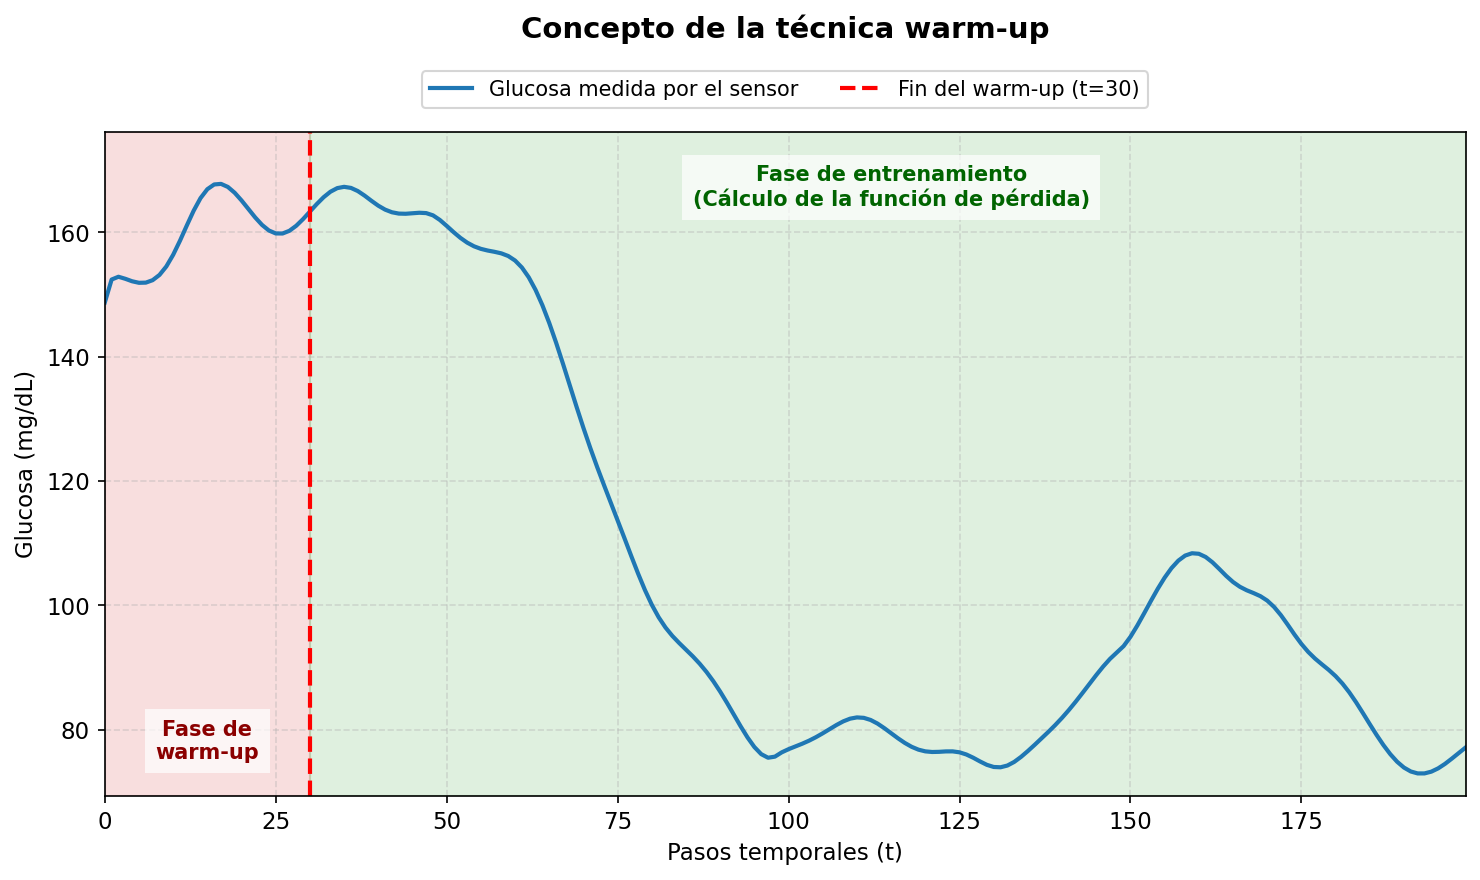

In [121]:
# Cogemos los primeros 200 valores de la glucosa (es la ventana definida)
total_steps = 200
y_glucose = df_patients["CGM"].values[:total_steps]
t = np.arange(total_steps)


# Grafico
plt.rcParams.update({"font.size": 11, "font.family": "sans-serif"})
fig, ax = plt.subplots(figsize = (10, 6), dpi = 150)
y_min, y_max = np.min(y_glucose) * 0.95, np.max(y_glucose) * 1.05
ax.set_xlim(0, total_steps - 1)
ax.set_ylim(y_min, y_max)

# Curva de glucosa
ax.plot(t, y_glucose, color = colors["blue"], linewidth = 2, label = "Glucosa medida por el sensor")

# Linea del warm-up, y separacion de antes y despues
warmup_steps = 30
ax.axvline(x = warmup_steps, color = "red", linestyle = "--", linewidth = 2, label = f'Fin del warm-up (t={warmup_steps})')
ax.axvspan(0, warmup_steps, color = colors["red"], alpha = 0.15)
ax.axvspan(warmup_steps, total_steps - 1, color = colors["green"], alpha = 0.15)


# Informacion del grafico
ax.text(warmup_steps / 2, y_min + (y_max - y_min) * 0.05, "Fase de\nwarm-up", 
        color = "darkred", weight = "bold", ha = "center", va = "bottom", fontsize = 10,
        bbox = dict(facecolor = "white", alpha = 0.7, edgecolor = "none", pad = 5))

ax.text(warmup_steps + (total_steps - warmup_steps) / 2, y_max - (y_max - y_min) * 0.05, "Fase de entrenamiento\n(Cálculo de la función de pérdida)",
        color = "darkgreen", weight = "bold", ha = "center", va = "top", fontsize = 10,
        bbox = dict(facecolor = "white", alpha = 0.7, edgecolor = "none", pad = 5))

ax.set_title("Concepto de la técnica warm-up", fontsize = 14, weight = "bold", pad = 45)

ax.legend(loc = "lower center", bbox_to_anchor = (0.5, 1.02), ncol = 2, frameon = True, shadow = False, fontsize = 10)
ax.set_xlabel("Pasos temporales (t)")
ax.set_ylabel("Glucosa (mg/dL)")
ax.grid(True, linestyle = "--", alpha = 0.4)

plt.tight_layout()
plt.show()

El proceso itera durante $50$ épocas, que no suponen un riesgo de *overfitting* debido al control con *Early Stopping* que existe en cada época.

In [122]:
epochs = 50
history_train_loss = []
history_val_loss = []

En el entrenamiento, añadimos el optimizador, el resolver para las EDOs con `odeint` y la función de pérdida, y por último, realizamos *backpropagation*. 

Además, debido a esta retropropagación, las derivadas tienden a multiplicarse. Para estabilizar el entrenamiento y evitar la explosión de gradientes frecuente en estos modelos, se aplica *gradient clipping*.

Época 1 / 50: 100%|██████████| 199/199 [14:38<00:00,  4.41s/it, loss actual=0.5863]


Época: 1 | TRAIN Loss: 0.5096 | VALIDATION Loss: 0.6331
  --- Mejora de inf a 0.6331. Modelo guardado.


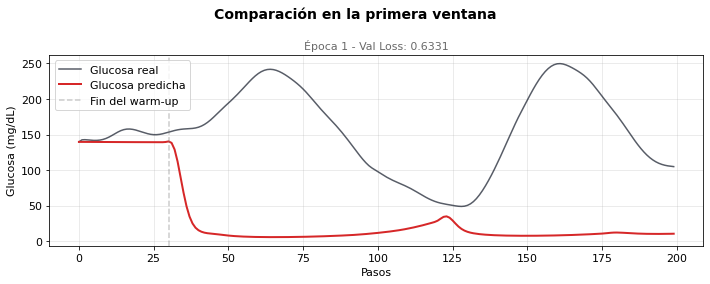

Época 2 / 50: 100%|██████████| 199/199 [14:33<00:00,  4.39s/it, loss actual=0.8375]


Época: 2 | TRAIN Loss: 0.4894 | VALIDATION Loss: 0.6128
  --- Mejora de 0.6331 a 0.6128. Modelo guardado.


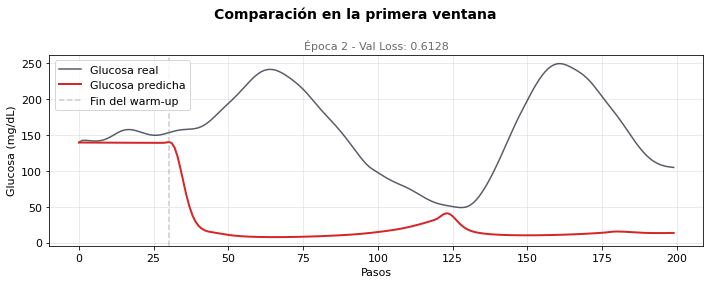

Época 3 / 50: 100%|██████████| 199/199 [14:42<00:00,  4.44s/it, loss actual=0.6415]


Época: 3 | TRAIN Loss: 0.4586 | VALIDATION Loss: 0.5829
  --- Mejora de 0.6128 a 0.5829. Modelo guardado.


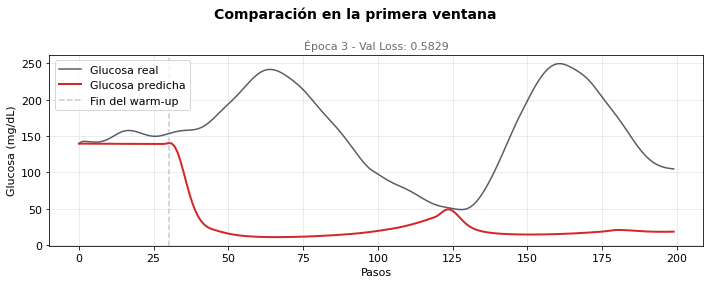

Época 4 / 50: 100%|██████████| 199/199 [14:33<00:00,  4.39s/it, loss actual=0.5544]


Época: 4 | TRAIN Loss: 0.4178 | VALIDATION Loss: 0.5431
  --- Mejora de 0.5829 a 0.5431. Modelo guardado.


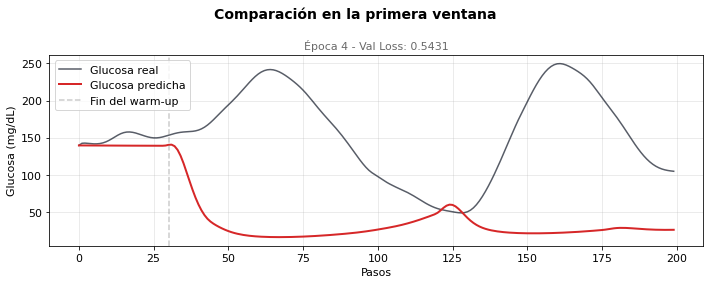

Época 5 / 50: 100%|██████████| 199/199 [14:34<00:00,  4.39s/it, loss actual=0.2609]


Época: 5 | TRAIN Loss: 0.3707 | VALIDATION Loss: 0.5004
  --- Mejora de 0.5431 a 0.5004. Modelo guardado.


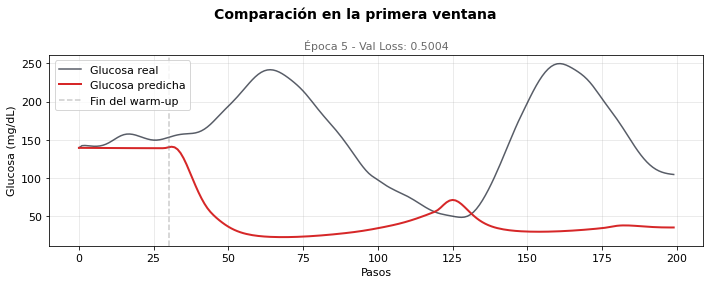

Época 6 / 50: 100%|██████████| 199/199 [14:32<00:00,  4.38s/it, loss actual=0.4298]


Época: 6 | TRAIN Loss: 0.3306 | VALIDATION Loss: 0.4640
  --- Mejora de 0.5004 a 0.4640. Modelo guardado.


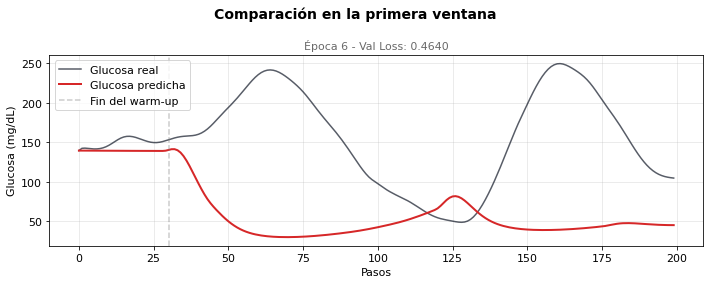

Época 7 / 50: 100%|██████████| 199/199 [14:36<00:00,  4.41s/it, loss actual=0.1627]


Época: 7 | TRAIN Loss: 0.2990 | VALIDATION Loss: 0.4356
  --- Mejora de 0.4640 a 0.4356. Modelo guardado.


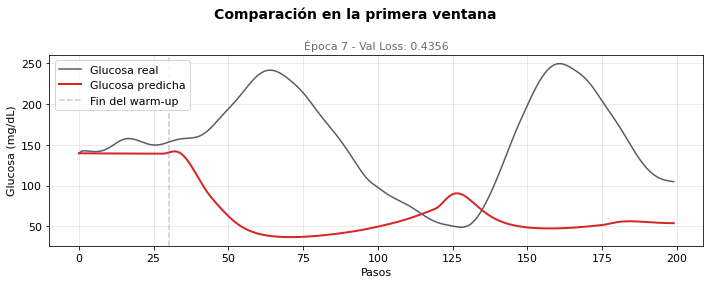

Época 8 / 50: 100%|██████████| 199/199 [14:30<00:00,  4.37s/it, loss actual=0.2593]


Época: 8 | TRAIN Loss: 0.2786 | VALIDATION Loss: 0.4137
  --- Mejora de 0.4356 a 0.4137. Modelo guardado.


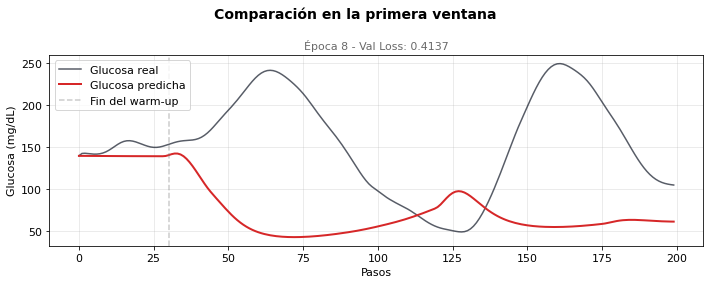

Época 9 / 50: 100%|██████████| 199/199 [14:31<00:00,  4.38s/it, loss actual=0.2058]


Época: 9 | TRAIN Loss: 0.2638 | VALIDATION Loss: 0.3960
  --- Mejora de 0.4137 a 0.3960. Modelo guardado.


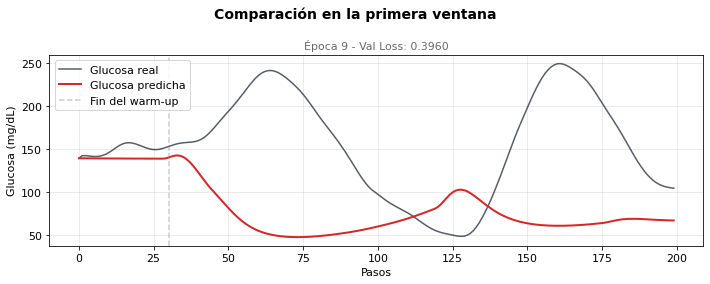

Época 10 / 50: 100%|██████████| 199/199 [14:24<00:00,  4.34s/it, loss actual=0.1748]


Época: 10 | TRAIN Loss: 0.2533 | VALIDATION Loss: 0.3814
  --- Mejora de 0.3960 a 0.3814. Modelo guardado.


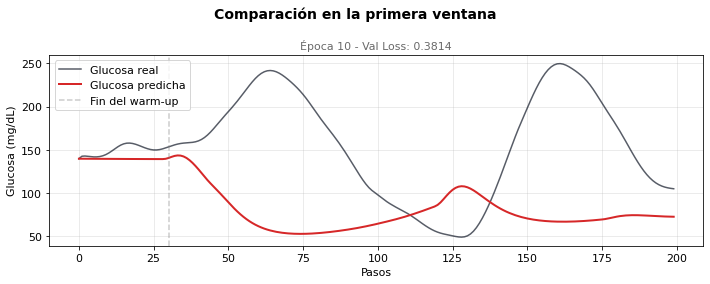

Época 11 / 50: 100%|██████████| 199/199 [14:32<00:00,  4.38s/it, loss actual=0.2033]


Época: 11 | TRAIN Loss: 0.2456 | VALIDATION Loss: 0.3689
  --- Mejora de 0.3814 a 0.3689. Modelo guardado.


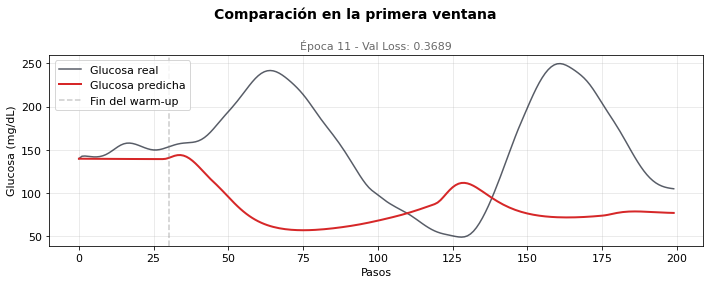

Época 12 / 50: 100%|██████████| 199/199 [14:31<00:00,  4.38s/it, loss actual=0.1629]


Época: 12 | TRAIN Loss: 0.2391 | VALIDATION Loss: 0.3579
  --- Mejora de 0.3689 a 0.3579. Modelo guardado.


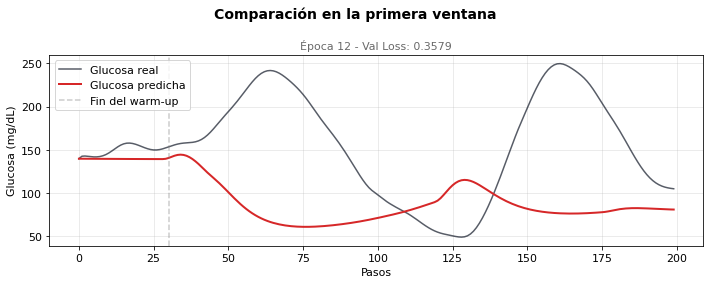

Época 13 / 50: 100%|██████████| 199/199 [14:26<00:00,  4.35s/it, loss actual=0.2291]


Época: 13 | TRAIN Loss: 0.2339 | VALIDATION Loss: 0.3481
  --- Mejora de 0.3579 a 0.3481. Modelo guardado.


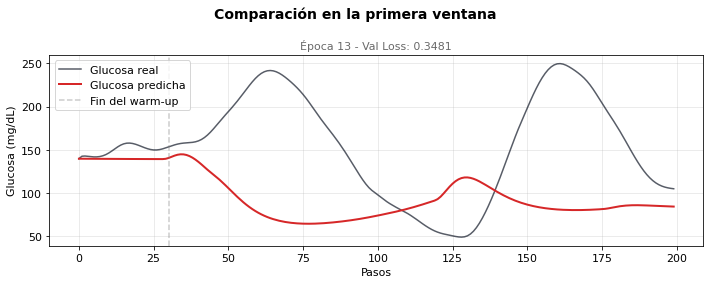

Época 14 / 50: 100%|██████████| 199/199 [14:32<00:00,  4.38s/it, loss actual=0.1421]


Época: 14 | TRAIN Loss: 0.2286 | VALIDATION Loss: 0.3390
  --- Mejora de 0.3481 a 0.3390. Modelo guardado.


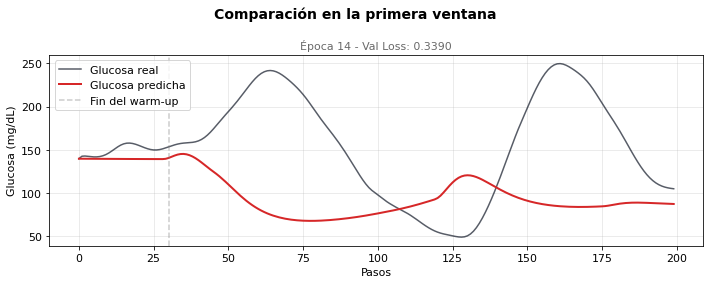

Época 15 / 50: 100%|██████████| 199/199 [20:19<00:00,  6.13s/it, loss actual=0.1446]


Época: 15 | TRAIN Loss: 0.2239 | VALIDATION Loss: 0.3300
  --- Mejora de 0.3390 a 0.3300. Modelo guardado.


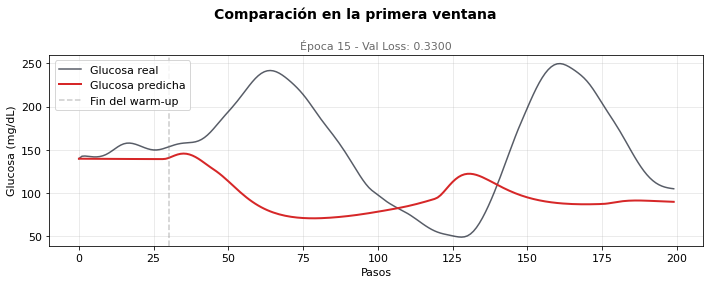

Época 16 / 50: 100%|██████████| 199/199 [24:37<00:00,  7.43s/it, loss actual=0.2020]


Época: 16 | TRAIN Loss: 0.2192 | VALIDATION Loss: 0.3201
  --- Mejora de 0.3300 a 0.3201. Modelo guardado.


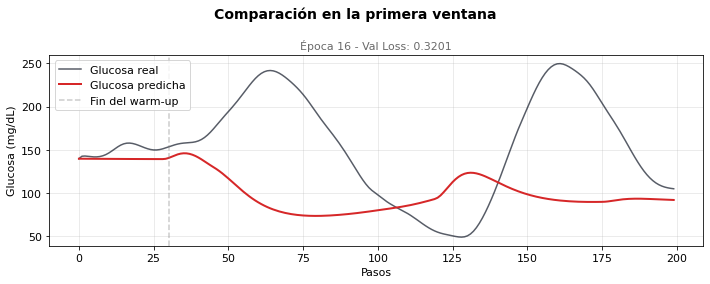

Época 17 / 50: 100%|██████████| 199/199 [24:24<00:00,  7.36s/it, loss actual=0.1944]


Época: 17 | TRAIN Loss: 0.2134 | VALIDATION Loss: 0.3086
  --- Mejora de 0.3201 a 0.3086. Modelo guardado.


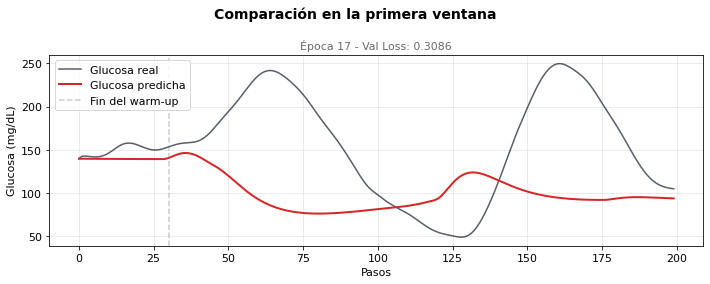

Época 18 / 50: 100%|██████████| 199/199 [24:24<00:00,  7.36s/it, loss actual=0.1734]


Época: 18 | TRAIN Loss: 0.2066 | VALIDATION Loss: 0.2956
  --- Mejora de 0.3086 a 0.2956. Modelo guardado.


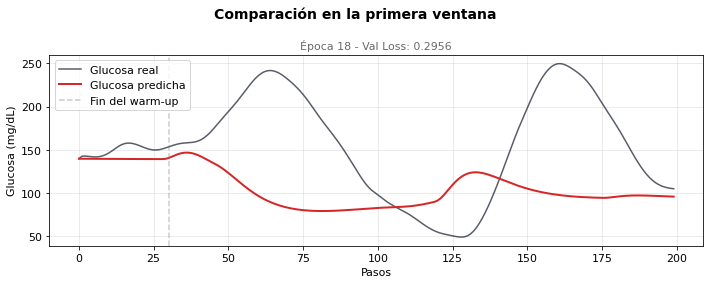

Época 19 / 50: 100%|██████████| 199/199 [24:22<00:00,  7.35s/it, loss actual=0.1578]


Época: 19 | TRAIN Loss: 0.2001 | VALIDATION Loss: 0.2830
  --- Mejora de 0.2956 a 0.2830. Modelo guardado.


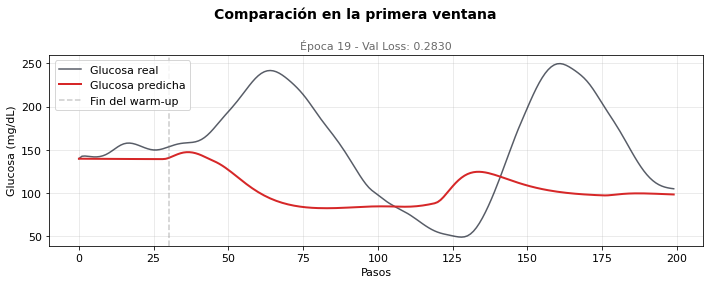

Época 20 / 50: 100%|██████████| 199/199 [24:27<00:00,  7.38s/it, loss actual=0.1295]


Época: 20 | TRAIN Loss: 0.1947 | VALIDATION Loss: 0.2719
  --- Mejora de 0.2830 a 0.2719. Modelo guardado.


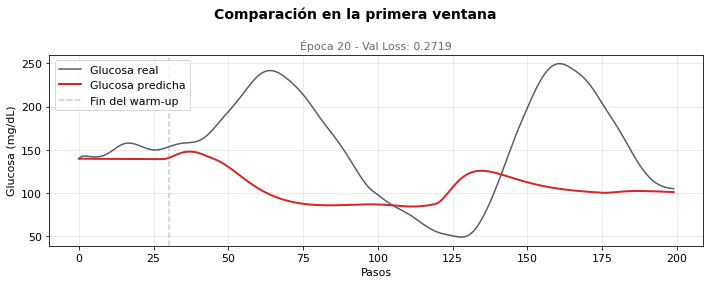

Época 21 / 50: 100%|██████████| 199/199 [24:27<00:00,  7.38s/it, loss actual=0.1489]


Época: 21 | TRAIN Loss: 0.1906 | VALIDATION Loss: 0.2625
  --- Mejora de 0.2719 a 0.2625. Modelo guardado.


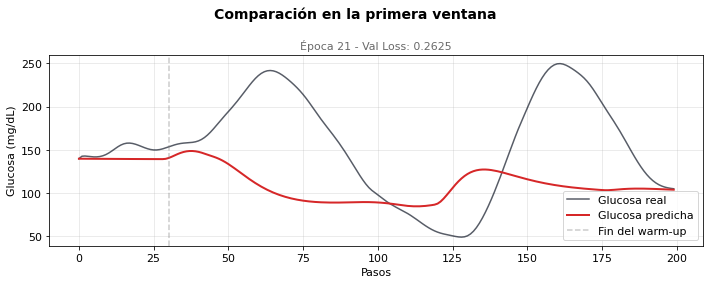

Época 22 / 50: 100%|██████████| 199/199 [24:21<00:00,  7.34s/it, loss actual=0.2364]


Época: 22 | TRAIN Loss: 0.1875 | VALIDATION Loss: 0.2544
  --- Mejora de 0.2625 a 0.2544. Modelo guardado.


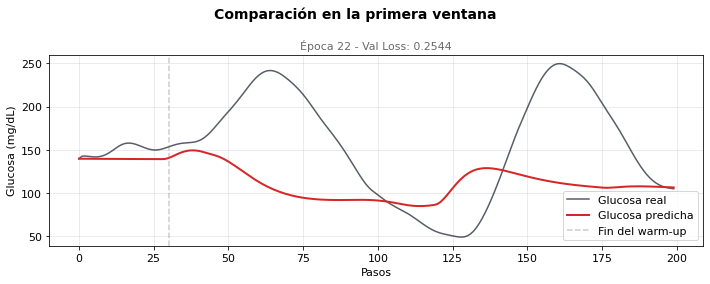

Época 23 / 50: 100%|██████████| 199/199 [24:26<00:00,  7.37s/it, loss actual=0.2887]


Época: 23 | TRAIN Loss: 0.1849 | VALIDATION Loss: 0.2475
  --- Mejora de 0.2544 a 0.2475. Modelo guardado.


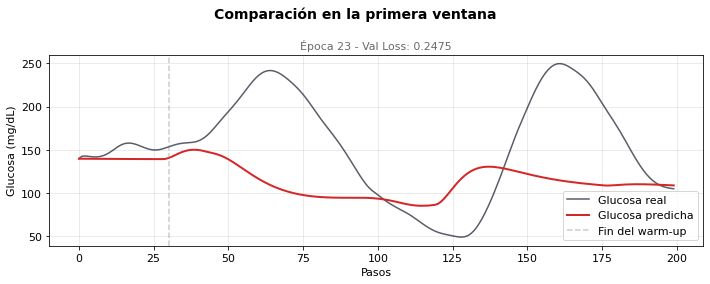

Época 24 / 50: 100%|██████████| 199/199 [24:24<00:00,  7.36s/it, loss actual=0.1078]


Época: 24 | TRAIN Loss: 0.1818 | VALIDATION Loss: 0.2415
  --- Mejora de 0.2475 a 0.2415. Modelo guardado.


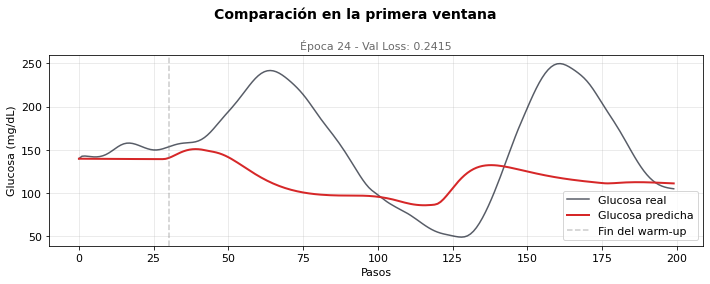

Época 25 / 50: 100%|██████████| 199/199 [24:27<00:00,  7.37s/it, loss actual=0.2110]


Época: 25 | TRAIN Loss: 0.1802 | VALIDATION Loss: 0.2358
  --- Mejora de 0.2415 a 0.2358. Modelo guardado.


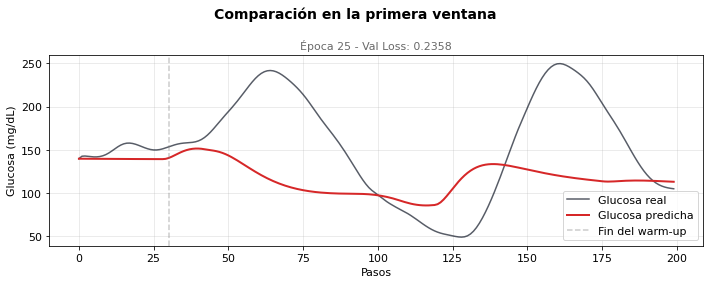

Época 26 / 50: 100%|██████████| 199/199 [25:34<00:00,  7.71s/it, loss actual=0.1114]


Época: 26 | TRAIN Loss: 0.1780 | VALIDATION Loss: 0.2310
  --- Mejora de 0.2358 a 0.2310. Modelo guardado.


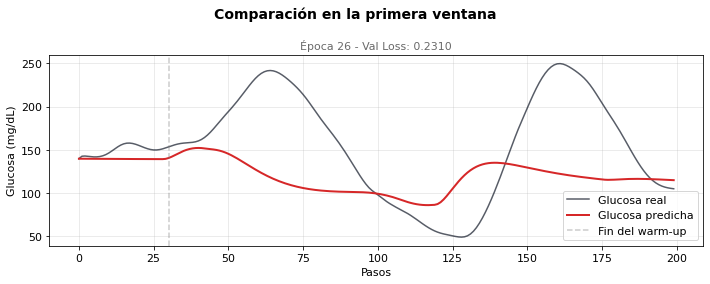

Época 27 / 50: 100%|██████████| 199/199 [26:56<00:00,  8.12s/it, loss actual=0.1300]


Época: 27 | TRAIN Loss: 0.1766 | VALIDATION Loss: 0.2265
  --- Mejora de 0.2310 a 0.2265. Modelo guardado.


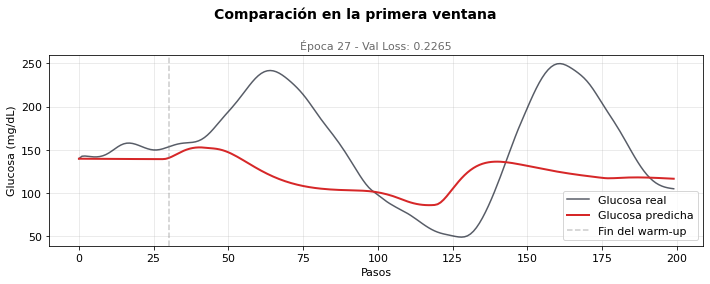

Época 28 / 50: 100%|██████████| 199/199 [26:55<00:00,  8.12s/it, loss actual=0.0623]


Época: 28 | TRAIN Loss: 0.1750 | VALIDATION Loss: 0.2226
  --- Mejora de 0.2265 a 0.2226. Modelo guardado.


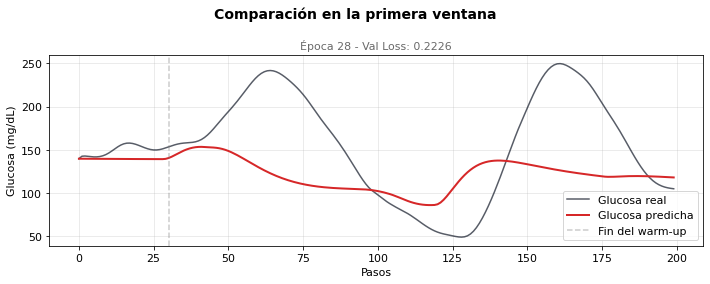

Época 29 / 50: 100%|██████████| 199/199 [27:05<00:00,  8.17s/it, loss actual=0.1714]


Época: 29 | TRAIN Loss: 0.1743 | VALIDATION Loss: 0.2192
  --- Mejora de 0.2226 a 0.2192. Modelo guardado.


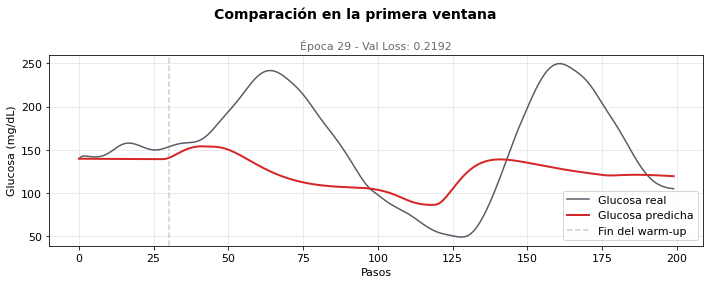

Época 30 / 50: 100%|██████████| 199/199 [25:15<00:00,  7.62s/it, loss actual=0.2077]


Época: 30 | TRAIN Loss: 0.1733 | VALIDATION Loss: 0.2161
  --- Mejora de 0.2192 a 0.2161. Modelo guardado.


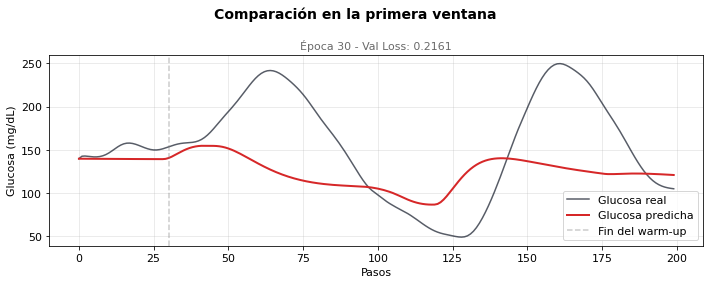

Época 31 / 50: 100%|██████████| 199/199 [25:41<00:00,  7.75s/it, loss actual=0.0696]


Época: 31 | TRAIN Loss: 0.1718 | VALIDATION Loss: 0.2130
  --- Mejora de 0.2161 a 0.2130. Modelo guardado.


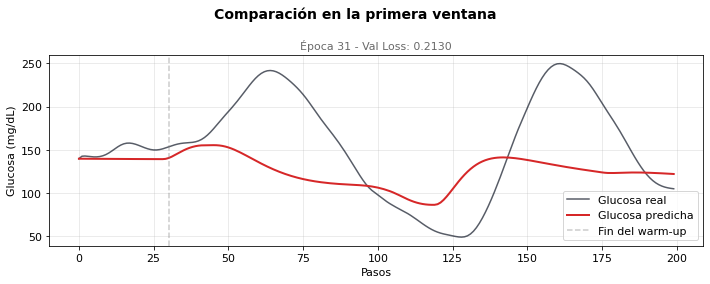

Época 32 / 50: 100%|██████████| 199/199 [27:14<00:00,  8.21s/it, loss actual=0.1077]


Época: 32 | TRAIN Loss: 0.1711 | VALIDATION Loss: 0.2102
  --- Mejora de 0.2130 a 0.2102. Modelo guardado.


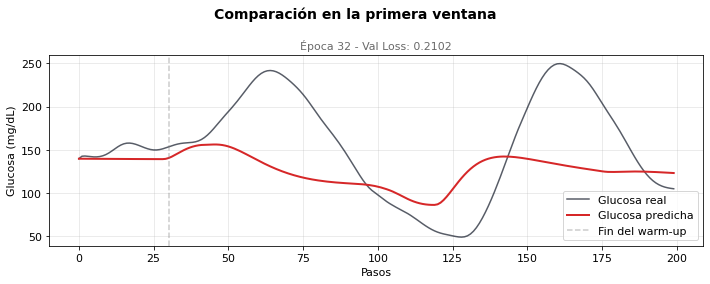

Época 33 / 50: 100%|██████████| 199/199 [27:08<00:00,  8.19s/it, loss actual=0.1024]


Época: 33 | TRAIN Loss: 0.1703 | VALIDATION Loss: 0.2078
  --- Mejora de 0.2102 a 0.2078. Modelo guardado.


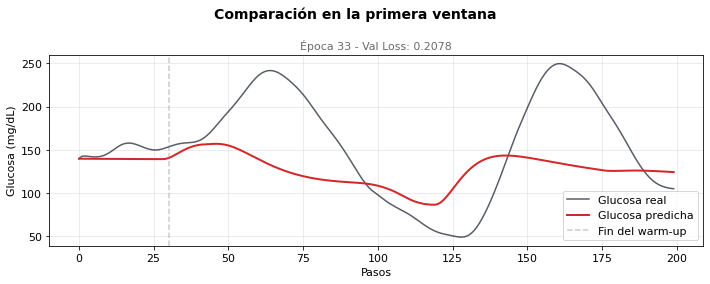

Época 34 / 50: 100%|██████████| 199/199 [26:51<00:00,  8.10s/it, loss actual=0.1031]


Época: 34 | TRAIN Loss: 0.1696 | VALIDATION Loss: 0.2055
  --- Mejora de 0.2078 a 0.2055. Modelo guardado.


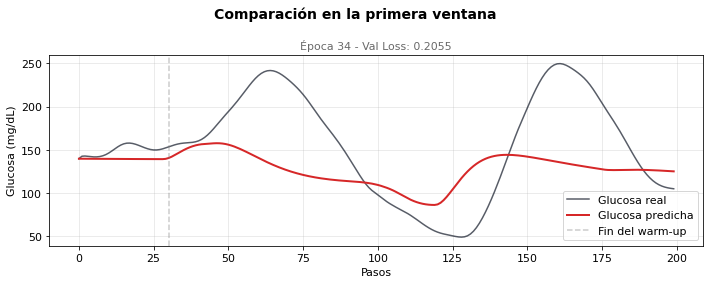

Época 35 / 50: 100%|██████████| 199/199 [26:50<00:00,  8.10s/it, loss actual=0.2277]


Época: 35 | TRAIN Loss: 0.1694 | VALIDATION Loss: 0.2035
  --- Mejora de 0.2055 a 0.2035. Modelo guardado.


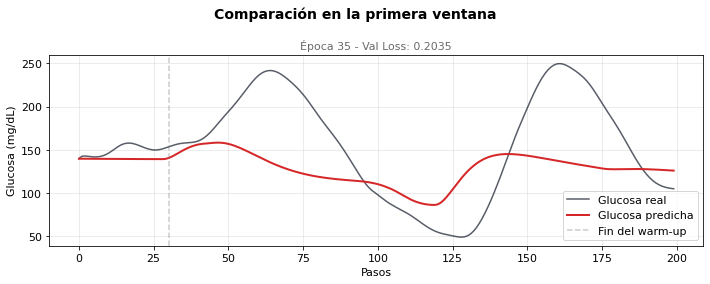

Época 36 / 50: 100%|██████████| 199/199 [26:54<00:00,  8.12s/it, loss actual=0.2628]


Época: 36 | TRAIN Loss: 0.1690 | VALIDATION Loss: 0.2017
  --- Mejora de 0.2035 a 0.2017. Modelo guardado.


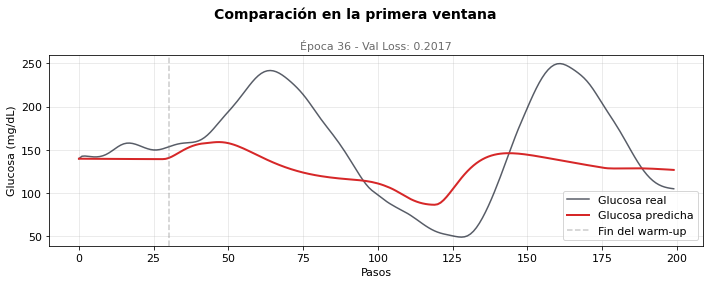

Época 37 / 50: 100%|██████████| 199/199 [26:43<00:00,  8.06s/it, loss actual=0.1380]


Época: 37 | TRAIN Loss: 0.1679 | VALIDATION Loss: 0.2001
  --- Mejora de 0.2017 a 0.2001. Modelo guardado.


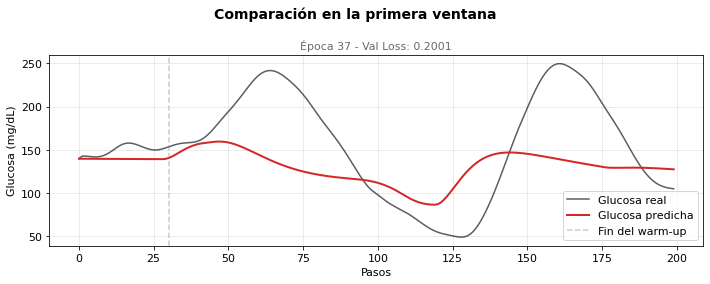

Época 38 / 50: 100%|██████████| 199/199 [26:55<00:00,  8.12s/it, loss actual=0.2005]


Época: 38 | TRAIN Loss: 0.1677 | VALIDATION Loss: 0.1984
  --- Mejora de 0.2001 a 0.1984. Modelo guardado.


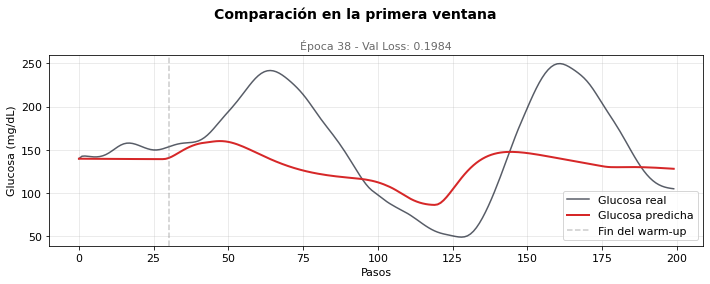

Época 39 / 50: 100%|██████████| 199/199 [27:06<00:00,  8.17s/it, loss actual=0.1471]


Época: 39 | TRAIN Loss: 0.1669 | VALIDATION Loss: 0.1971
  --- Mejora de 0.1984 a 0.1971. Modelo guardado.


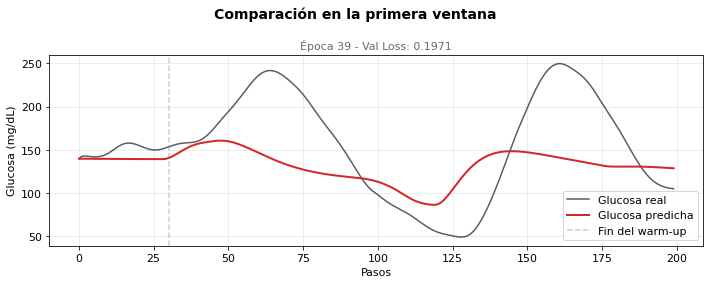

Época 40 / 50: 100%|██████████| 199/199 [26:42<00:00,  8.05s/it, loss actual=0.2094]


Época: 40 | TRAIN Loss: 0.1667 | VALIDATION Loss: 0.1955
  --- Mejora de 0.1971 a 0.1955. Modelo guardado.


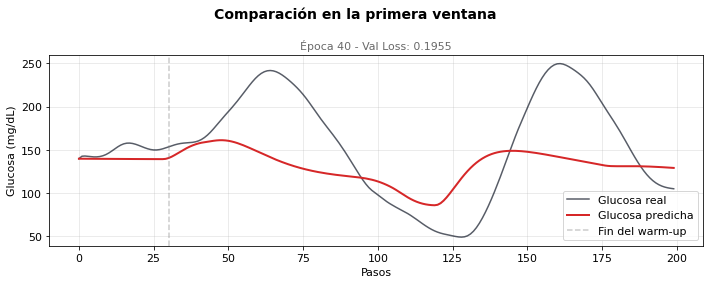

Época 41 / 50: 100%|██████████| 199/199 [26:56<00:00,  8.12s/it, loss actual=0.0941]


Época: 41 | TRAIN Loss: 0.1658 | VALIDATION Loss: 0.1945
  --- Mejora de 0.1955 a 0.1945. Modelo guardado.


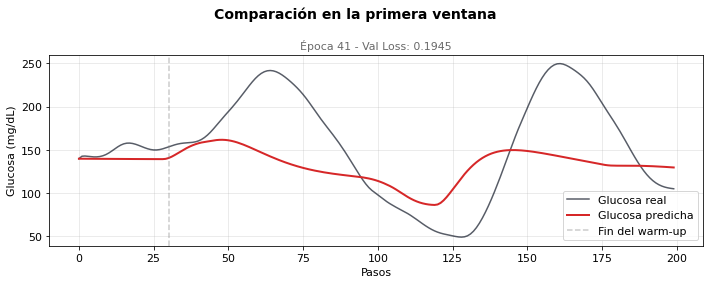

Época 42 / 50: 100%|██████████| 199/199 [26:50<00:00,  8.09s/it, loss actual=0.1113]


Época: 42 | TRAIN Loss: 0.1654 | VALIDATION Loss: 0.1936
  --- Mejora de 0.1945 a 0.1936. Modelo guardado.


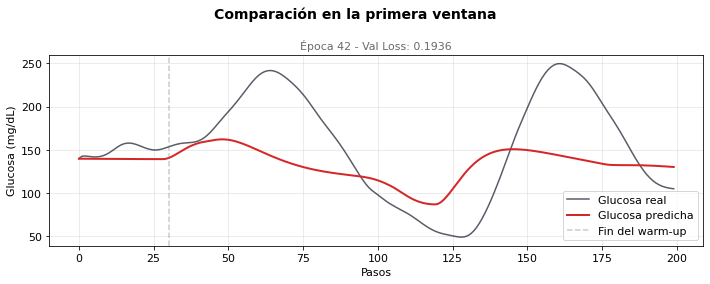

Época 43 / 50: 100%|██████████| 199/199 [26:48<00:00,  8.09s/it, loss actual=0.4534]


Época: 43 | TRAIN Loss: 0.1665 | VALIDATION Loss: 0.1922
  --- Mejora de 0.1936 a 0.1922. Modelo guardado.


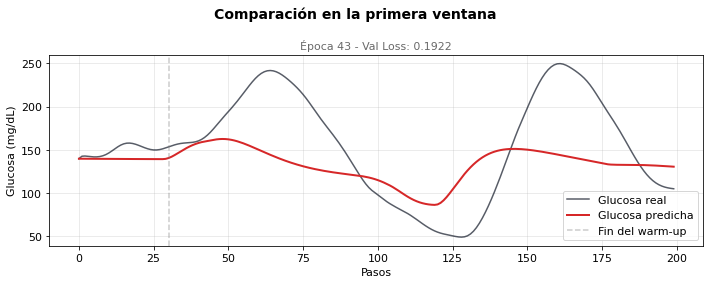

Época 44 / 50: 100%|██████████| 199/199 [26:38<00:00,  8.03s/it, loss actual=0.1136]


Época: 44 | TRAIN Loss: 0.1647 | VALIDATION Loss: 0.1913
  --- Mejora de 0.1922 a 0.1913. Modelo guardado.


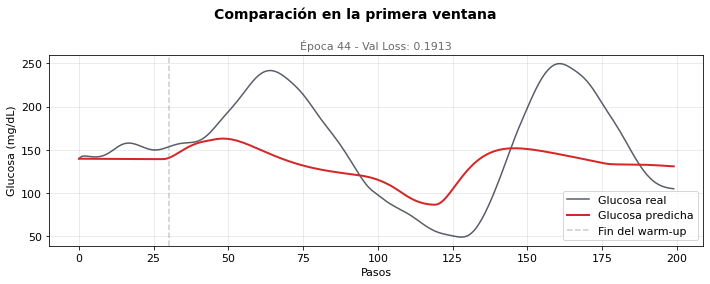

Época 45 / 50: 100%|██████████| 199/199 [26:40<00:00,  8.04s/it, loss actual=0.0939]


Época: 45 | TRAIN Loss: 0.1642 | VALIDATION Loss: 0.1904
  --- Mejora de 0.1913 a 0.1904. Modelo guardado.


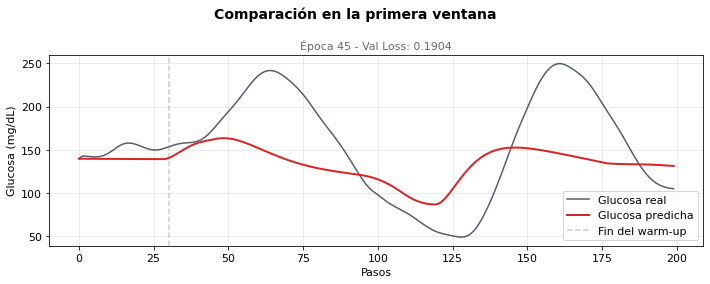

Época 46 / 50: 100%|██████████| 199/199 [26:32<00:00,  8.00s/it, loss actual=0.2828]


Época: 46 | TRAIN Loss: 0.1646 | VALIDATION Loss: 0.1895
  --- Mejora de 0.1904 a 0.1895. Modelo guardado.


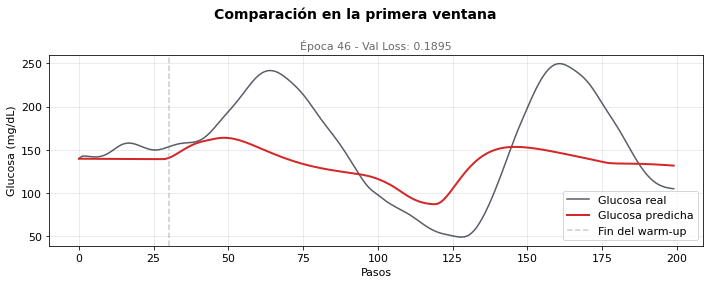

Época 47 / 50: 100%|██████████| 199/199 [26:34<00:00,  8.01s/it, loss actual=0.0918]


Época: 47 | TRAIN Loss: 0.1634 | VALIDATION Loss: 0.1884
  --- Mejora de 0.1895 a 0.1884. Modelo guardado.


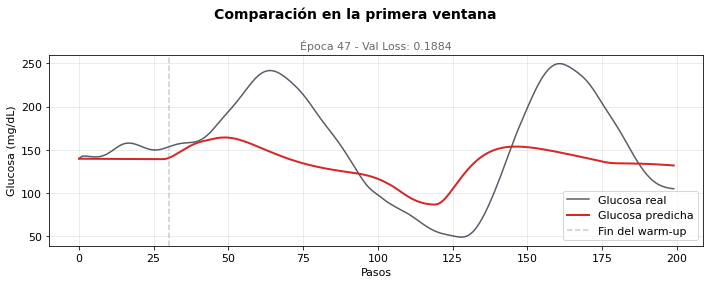

Época 48 / 50: 100%|██████████| 199/199 [26:12<00:00,  7.90s/it, loss actual=0.1340]


Época: 48 | TRAIN Loss: 0.1633 | VALIDATION Loss: 0.1874
  --- Mejora de 0.1884 a 0.1874. Modelo guardado.


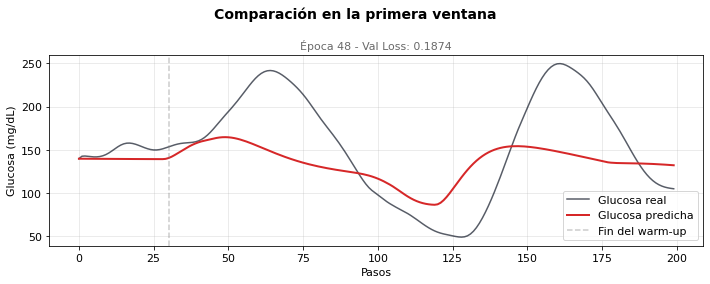

Época 49 / 50: 100%|██████████| 199/199 [24:25<00:00,  7.37s/it, loss actual=0.1416]


Época: 49 | TRAIN Loss: 0.1630 | VALIDATION Loss: 0.1866
  --- Mejora de 0.1874 a 0.1866. Modelo guardado.


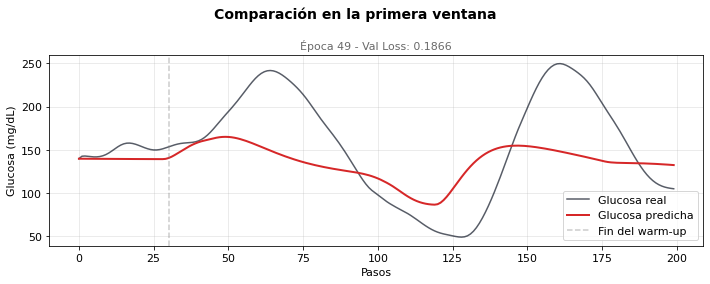

Época 50 / 50: 100%|██████████| 199/199 [24:30<00:00,  7.39s/it, loss actual=0.1124]


Época: 50 | TRAIN Loss: 0.1625 | VALIDATION Loss: 0.1859
  --- Mejora de 0.1866 a 0.1859. Modelo guardado.


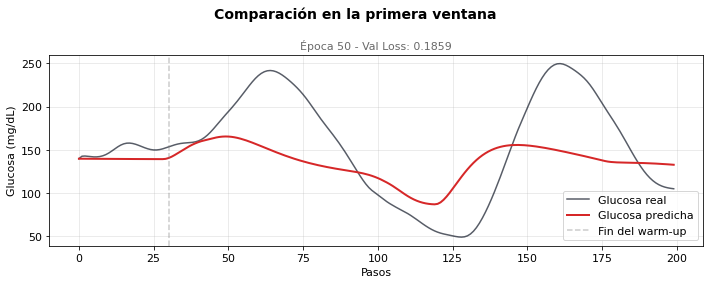

In [123]:
for epoch in range(epochs):

    # ENTRENAMIENTO
    
    total_train_loss = 0
    p3_net.train()
    
    # Barra de progreso -> avanza una unidad por cada batch que se procesa
    progress_bar = tqdm(train_loader, desc = f"Época {epoch + 1} / {epochs}", colour = "blue")

    for batch in progress_bar:

        # Eliminamos los gradientes del paso anterior
        optimizer.zero_grad() 

        # Valores de glucosa y tiempo del batch actual
        target_glucose = batch["target"]
        t_vector = batch["t"][0]

        # Generamos el estado inicial de las variables
        G0_real = batch["y0"][:, 0]
        initial_difference = G0_real - target_glucose[:, 5]
        X0 = torch.clamp(initial_difference * 0.001, min = 0.0)
        I0 = torch.ones_like(G0_real)
        y0 = torch.stack([G0_real, X0, I0], dim = 1)
        
        # Definimos las EDOs del modelo de Bergman
        bergman_odes = HybridBergmanModel(p3_net, batch)
        bergman_odes.p3_history = []

        # Resolvemos las EDOs con el estado actual del modelo 
        # Obtenemos, en orden: dG / dt, dX / dt, dI / dt
        prediction = odeint(bergman_odes, y0, t_vector, method = "rk4", options = {"step_size": 1.0})

        p3_values = torch.stack(bergman_odes.p3_history).flatten()
        pred_glucose = prediction[:, :, 0].transpose(0, 1)

        # Decidimos cuantos pasos usamos para el warm-up
        warmup_steps = 30

        # Recortamos la prediccion y el target para ignorar los primeros 30 pasos
        pred_glucose_eval = pred_glucose[:, warmup_steps:]
        target_glucose_eval = target_glucose[:, warmup_steps:]
        p3_values_eval = torch.stack(bergman_odes.p3_history[warmup_steps:]).flatten()

        # Calculamos la loss con la funcion de perdida
        loss = loss_function(pred_glucose_eval, target_glucose_eval, p3_values_eval)

        # Backpropagation del error
        loss.backward()

        # Para prevenir que los gradientes exploten
        torch.nn.utils.clip_grad_norm_(p3_net.parameters(), max_norm = 1.0)
        
        # Actualizamos los parametros del modelo
        optimizer.step()     

        # Acumulamos el error
        total_train_loss += loss.item()
        progress_bar.set_postfix({"loss actual": f"{loss.item():.4f}"})



    
    # VALIDACION
    
    p3_net.eval()
    total_val_loss = 0
    plot_real = None
    plot_pred = None

    # En validacion, se desactiva el calculo de gradientes
    with torch.no_grad():
        for batch_val in val_loader:

            # Valores de glucosa y tiempo del batch actual
            target_glucose = batch_val["target"]
            t_vector = batch_val["t"][0]
            
            # Generamos el estado inicial de las variables
            G0_real = batch_val["y0"][:, 0]
            initial_difference = G0_real - target_glucose[:, 5]
            X0 = torch.clamp(initial_difference * 0.001, min = 0.0)
            I0 = torch.ones_like(G0_real)
            y0 = torch.stack([G0_real, X0, I0], dim = 1)

            # Definimos las EDOs del modelo de Bergman
            bergman_odes = HybridBergmanModel(p3_net, batch_val)
            bergman_odes.p3_history = []

            # Resolvemos las EDOs con el estado actual del modelo 
            prediction = odeint(bergman_odes, y0, t_vector, method = "rk4", options = {"step_size": 1.0})
            pred_glucose = prediction[:, :, 0].transpose(0, 1)

            # Realizamos el warm-up y recortamos las señales
            warmup_steps = 30
            pred_glucose_eval = pred_glucose[:, warmup_steps:]
            target_glucose_eval = target_glucose[:, warmup_steps:]
            p3_values_eval = torch.stack(bergman_odes.p3_history[warmup_steps:]).flatten()

            # Calculamos la loss con la funcion de perdida
            loss = loss_function(pred_glucose_eval, target_glucose_eval, p3_values_eval)
            total_val_loss += loss.item()

            # Guardamos la primera ventana del primer batch para representar
            if plot_real is None:
                gb_val = batch_val["Gb"][0].item()
                plot_real = target_glucose[0].detach().cpu().numpy() * gb_val
                plot_pred = pred_glucose[0].detach().cpu().numpy() * gb_val

    
    # RESULTADOS EPOCA
    average_train_loss = total_train_loss / len(train_loader)
    average_val_loss = total_val_loss / len(val_loader)

    print(f"Época: {epoch + 1} | TRAIN Loss: {average_train_loss:.4f} | VALIDATION Loss: {average_val_loss:.4f}")
    
    history_train_loss.append(average_train_loss)
    history_val_loss.append(average_val_loss)

    
    # EARLY STOPPING
    early_stopping(average_val_loss, p3_net)
    if early_stopping.early_stop:
        print(f"  --- EARLY STOPPING: El modelo no está mejorando más.")
        break

    
    # GRAFICA DE LA PRIMERA VENTANA
    plt.figure(figsize = (10, 4))
    plt.plot(plot_real, label = "Glucosa real", color = colors["black"], alpha = 0.7)
    plt.plot(plot_pred, label = "Glucosa predicha", color = colors["red"], linewidth = 2)
    plt.axvline(x = 30, color = "gray", linestyle = "--", alpha = 0.4, label = "Fin del warm-up")

    plt.suptitle("Comparación en la primera ventana", fontsize = 14, fontweight = "bold")
    plt.title(f"Época {epoch + 1} - Val Loss: {average_val_loss:.4f}", fontsize = 11, color = "dimgray")
    plt.ylabel("Glucosa (mg/dL)")
    plt.xlabel("Pasos")
    plt.legend()
    plt.grid(True, alpha = 0.3)
    plt.tight_layout()
    plt.show()

## 16. Evaluación del modelo

In [126]:
# Cargamos el mejor modelo
print("Cargando el mejor modelo detectado durante el entrenamiento...")
early_stopping.load_best_model(p3_net)
torch.save(p3_net.state_dict(), "bergman_best_model.pth")

Cargando el mejor modelo detectado durante el entrenamiento...


### 16.1. Fase de evaluación

A continuación, se ejecuta la fase de evaluación para **comparar el rendimiento de los dos enfoques del modelo de Bergman**: el modelo híbrido (donde la red neuronal predice dinámicamente el parámetro $p_3$) y el modelo original (que utiliza un valor constante para $p_3$). 

El objetivo es iterar sobre los datos de prueba, simular la evolución de la glucosa resolviendo las ecuaciones diferenciales ordinarias para ambos modelos y extraer las predicciones.

In [ ]:
# Ponemos la red en modo evaluación
p3_net.eval()

raw_windows = []
seen_patients = set()   # pacientes procesados

# En test, se desactiva el calculo de gradientes
with torch.no_grad():
    for batch_test in test_loader:

        # Valores de glucosa, glucosa basal y tiempo del batch actual
        target_glucose = batch_test["target"]
        Gb = batch_test["Gb"]
        t_vector = batch_test["t"][0]

        # IDs de los pacientes del batch actual
        pids = batch_test["patient_id"]

        # Generamos el estado inicial de las variables
        G0_real = batch_test["y0"][:, 0]
        current_batch_size = G0_real.shape[0]
        initial_difference = G0_real - target_glucose[:, 0]
        X0 = torch.clamp(initial_difference * 0.001, min = 0.0)
        I0 = torch.ones_like(G0_real)
        y0 = torch.stack([G0_real, X0, I0], dim = 1)

        
        # MODELO HIBRIDO
        
        # Definimos las EDOs del modelo de Bergman hibrido
        hybrid_odes = HybridBergmanModel(p3_net, batch_test)

        # Resolvemos las EDOs con el estado actual del modelo 
        prediction_hybrid = odeint(hybrid_odes, y0, t_vector, method = "rk4", options = {"step_size": 1.0})

        # Calculamos la media del parametro p3 predicho por el modelo
        p3_mean = torch.stack(hybrid_odes.p3_history).mean().item()
        print(f"El p3 medio del modelo híbrido es: {p3_mean}")

        
        # MODELO CLASICO
        
        # Definimos las EDOs del modelo de Bergman original
        classic_odes = ClassicBergmanModel(batch_test, p3_constant = 5e-5)

        # Resolvemos la EDO con el estado actual del modelo 
        prediction_classic = odeint(classic_odes, y0, t_vector, method = "rk4", options = {"step_size": 1.0})


        
        # RESULTADOS

        # Recorremos cada paciente dentro del batch actual
        for i in range(current_batch_size):

            # ID del paciente
            pid_full = pids[i] if isinstance(pids, list) else pids[i]
            original_id = pid_full.split('_win_')[0] if isinstance(pid_full, str) else pid_full

            # Extraemos las predicciones y la glucosa real medida por el sensor
            pred_hybrid_norm = prediction_hybrid[:, i, 0].cpu().numpy()
            pred_classic_norm = prediction_classic[:, i, 0].cpu().numpy()
            real_glucose_norm = target_glucose[i].cpu().numpy()

            # Glucosa basal del paciente para desnormalizar
            gb_p = Gb[i].item()

            if original_id not in seen_patients:
                # Si es la primera vez que se ve a este paciente, guardamos la serie completa
                final_pred_hybrid = pred_hybrid_norm[:]
                final_pred_classic = pred_classic_norm[:]
                final_real_glucose = real_glucose_norm[:]

                seen_patients.add(original_id)

            else:
                # Si ya es una ventana consecutiva del mismo paciente, recortamos los pasos del warm-up
                final_pred_hybrid = pred_hybrid_norm[30:]
                final_pred_classic = pred_classic_norm[30:]
                final_real_glucose = real_glucose_norm[30:]

            
            raw_windows.append({
                "original_id": original_id,
                "real_glucose": (final_real_glucose * gb_p).copy(),
                "pred_hybrid": (final_pred_hybrid * gb_p).copy(),
                "pred_classic": (final_pred_classic * gb_p).copy(),
                "Gb": gb_p
            })

El p3 medio del modelo híbrido es: 4.9978250899584964e-05
El p3 medio del modelo híbrido es: 6.050748925190419e-05
El p3 medio del modelo híbrido es: 0.000104107144579757


### 16.2. Cálculo de métricas

Ahora, hay que reconstruir la línea temporal de glucosa completa de cada paciente a partir de los fragmentos individuales del *warm-up* que se calcularon en el paso anterior.

In [130]:
# Diccionario para guardar las series temporales completas de cada paciente
patients_joined = {}

In [131]:
for window in raw_windows:
    p_id = window["original_id"]
    
    if p_id not in patients_joined:
        patients_joined[p_id] = {"real_glucose": [], "pred_hybrid": [], "pred_classic": []}

    # Añadimos los datos de esta ventana al final de la lista del paciente
    patients_joined[p_id]["real_glucose"].extend(window["real_glucose"])
    patients_joined[p_id]["pred_hybrid"].extend(window["pred_hybrid"])
    patients_joined[p_id]["pred_classic"].extend(window["pred_classic"])

Después, agrupamos los datos de cada paciente en tres listas: una primera para los valores reales de la glucosa medida por el sensor CGM, una segunda para las predicciones del modelo híbrido y una tercera para las predicciones del modelo clásico.

In [132]:
all_real_glucose = []
all_pred_hybrid = []
all_pred_classic = []

In [133]:
# Recorremos todos los pacientes
for p_id in patients_joined:
    all_real_glucose.extend(patients_joined[p_id]["real_glucose"])
    all_pred_hybrid.extend(patients_joined[p_id]["pred_hybrid"])
    all_pred_classic.extend(patients_joined[p_id]["pred_classic"])

Por último, evaluamos la calidad de las predicciones usando cinco métricas:
- **MSE (Error Cuadrático Medio)**: mide el promedio de los errores al cuadrado. Como eleva las diferencias al cuadrado, penaliza mucho los errores grandes.

- **RMSE (Raíz del Error Cuadrático Medio)**: se calcula como la raíz cuadrada del MSE. Devuelve el valor del error en las unidades originales (mg/dL para la glucosa).

- **MAE (Error Absoluto Medio)**: mide el promedio de las diferencias absolutas entre las predicciones y los valores reales.

- **MAPE (Error Porcentual Absoluto Medio)**: expresa en porcentaje la desviación promedio entre el valor real y el valor predicho.

- **$R^2$ (Coeficiente de determinación)**: se trata de una métrica estadística empleada para determinar cómo de bien se ajustan las predicciones a los datos reales.

Para cuantificar la precisión y el rendimiento de ambos enfoques, se calculan las métricas de forma **global e individual** por paciente.

#### 16.2.1. Métricas globales

Por un lado, empleando las series completas de glucosa real y glucosa predicha por el modelo híbrido, se calculan las **métricas globales para el enfoque híbrido**.

In [134]:
# Metricas del modelo hibrido

overall_mse_hybrid = mean_squared_error(all_real_glucose, all_pred_hybrid)
overall_rmse_hybrid = np.sqrt(overall_mse_hybrid)
overall_mae_hybrid = mean_absolute_error(all_real_glucose, all_pred_hybrid)
overall_mape_hybrid = mean_absolute_percentage_error(all_real_glucose, all_pred_hybrid) * 100
overall_r2_hybrid = r2_score(all_real_glucose, all_pred_hybrid)

Por otro lado, con las series completas de glucosa real y glucosa predicha por el modelo clásico, se calculan las **métricas globales para el enfoque original**.

In [135]:
# Metricas del modelo clasico

overall_mse_classic = mean_squared_error(all_real_glucose, all_pred_classic)
overall_rmse_classic = np.sqrt(overall_mse_classic)
overall_mae_classic = mean_absolute_error(all_real_glucose, all_pred_classic)
overall_mape_classic = mean_absolute_percentage_error(all_real_glucose, all_pred_classic) * 100
overall_r2_classic = r2_score(all_real_glucose, all_pred_classic)

Con ambos cálculos por tipo de métrica, se calcula la **mejora porcentual** que supone emplear el modelo híbrido frente al clásico:

$$\Delta_{\text{Error}} (\%) = \frac{\text{Error}_{\text{clásico}} - \text{Error}_{\text{híbrido}}}{\text{Error}_{\text{clásico}}} \cdot 100$$

In [136]:
# Calculo porcentual de la mejora
# Fórmula: ( (Error clasico - Error hibrido) / Error clasico) * 100

improvement_mse = ((overall_mse_classic - overall_mse_hybrid) / overall_mse_classic) * 100
improvement_rmse = ((overall_rmse_classic - overall_rmse_hybrid) / overall_rmse_classic) * 100
improvement_mae = ((overall_mae_classic - overall_mae_hybrid) / overall_mae_classic) * 100
improvement_mape = ((overall_mape_classic - overall_mape_hybrid) / overall_mape_classic) * 100
improvement_r2 = ((overall_r2_hybrid - overall_r2_classic) / abs(overall_r2_classic)) * 100

In [137]:
print(f"\n--- MÉTRICAS GLOBALES EN TEST ---")


--- MÉTRICAS GLOBALES EN TEST ---


In [139]:
print(f"MODELO DE BERGMAN CLÁSICO):")
print(f"  - MSE: {overall_mse_classic:.2f} (mg/dL)^2")
print(f"  - RMSE: {overall_rmse_classic:.2f} mg/dL")    
print(f"  - MAE: {overall_mae_classic:.2f} mg/dL")
print(f"  - MAPE: {overall_mape_classic:.2f}%")
print(f"  - R^2: {overall_r2_classic:.4f}\n")

MODELO DE BERGMAN CLÁSICO):
  - MSE: 10035.99 (mg/dL)^2
  - RMSE: 100.18 mg/dL
  - MAE: 79.68 mg/dL
  - MAPE: 67.13%
  - R^2: -3.2611



In [140]:
print(f"MODELO DE BERGMAN HÍBRIDO:")
print(f"  - MSE: {overall_mse_hybrid:.2f} (mg/dL)^2 ---> Mejora del {improvement_mse:.1f}%")
print(f"  - RMSE: {overall_rmse_hybrid:.2f} mg/dL ---> Mejora del {improvement_rmse:.1f}%")    
print(f"  - MAE: {overall_mae_hybrid:.2f} mg/dL ---> Mejora del {improvement_mae:.1f}%")
print(f"  - MAPE: {overall_mape_hybrid:.2f}% ---> Mejora del {improvement_mape:.1f}%")
print(f"  - R^2: {overall_r2_hybrid:.4f} ---> Mejora del {improvement_r2:.1f}%\n")

MODELO DE BERGMAN HÍBRIDO:
  - MSE: 2136.45 (mg/dL)^2 ---> Mejora del 78.7%
  - RMSE: 46.22 mg/dL ---> Mejora del 53.9%
  - MAE: 36.73 mg/dL ---> Mejora del 53.9%
  - MAPE: 42.50% ---> Mejora del 36.7%
  - R^2: 0.0929 ---> Mejora del 102.8%



#### 16.2.2. Métricas individuales

Adicionalmente, además de calcular el error promedio de todo el conjunto de datos global, se evalúa el **rendimiento por paciente**.

Para ello, se calculan las métricas para el modelo clásico y para el híbrido, usando las trayectorias completas de glucosa de cada paciente. Asimismo, se cuantifica la mejora porcentual de las métricas para cada individuo.

In [141]:
patient_metrics = []

In [142]:
for p_id, data in patients_joined.items():
    
    y_real = np.array(data["real_glucose"])
    y_hybrid = np.array(data["pred_hybrid"])
    y_classic = np.array(data["pred_classic"])

    
    # METRICAS INDIVIDUALES
    
    # Metricas del modelo hibrido
    mse_hybrid = mean_squared_error(y_real, y_hybrid)
    rmse_hybrid = np.sqrt(mse_hybrid)
    mae_hybrid = mean_absolute_error(y_real, y_hybrid)
    mape_hybrid = mean_absolute_percentage_error(y_real, y_hybrid) * 100 
    r2_hybrid = r2_score(y_real, y_hybrid)
    
    # Metricas del modelo clasico
    mse_classic = mean_squared_error(y_real, y_classic)
    rmse_classic = np.sqrt(mse_classic)
    mae_classic = mean_absolute_error(y_real, y_classic)
    mape_classic = mean_absolute_percentage_error(y_real, y_classic) * 100
    r2_classic = r2_score(y_real, y_classic)

    
    # MEJORA PORCENTUAL
    
    mse_improvement = ((mse_classic - mse_hybrid) / mse_classic) * 100 if mse_classic != 0 else 0.0
    rmse_improvement = ((rmse_classic - rmse_hybrid) / rmse_classic) * 100 if rmse_classic != 0 else 0.0
    mae_improvement = ((mae_classic - mae_hybrid) / mae_classic) * 100 if mae_classic != 0 else 0.0
    mape_improvement = ((mape_classic - mape_hybrid) / mape_classic) * 100 if mape_classic != 0 else 0.0
    r2_improvement = ((r2_hybrid - r2_classic) / abs(r2_classic)) * 100 if r2_classic != 0 else 0.0
    
    
    # Almacenamos en un diccionario
    patient_metrics.append({
        "Paciente": p_id,
        "MSE_clasico": mse_classic,
        "MSE_hibrido": mse_hybrid,
        "Mejora_MSE_%": mse_improvement,
        
        "RMSE_clasico": rmse_classic,
        "RMSE_hibrido": rmse_hybrid,
        "Mejora_RMSE_%": rmse_improvement,
        
        "MAE_clasico": mae_classic,
        "MAE_hibrido": mae_hybrid,
        "Mejora_MAE_%": mae_improvement,
        
        "MAPE_clasico_%": mape_classic,
        "MAPE_hibrido_%": mape_hybrid,
        "Mejora_MAPE_%": mape_improvement,

        "R2_clasico": r2_classic,
        "R2_hibrido": r2_hybrid,
        "Mejora_R2_%": r2_improvement
    })

In [143]:
# Creamos un Dataframe de las metricas
df_metrics = pd.DataFrame(patient_metrics)

# Ordenamos de mayor a menor
df_metrics = df_metrics.sort_values(by = "Mejora_RMSE_%", ascending = False)
df_metrics.round(2)

,Paciente,MSE_clasico,MSE_hibrido,Mejora_MSE_%,RMSE_clasico,RMSE_hibrido,Mejora_RMSE_%,MAE_clasico,MAE_hibrido,Mejora_MAE_%,MAPE_clasico_%,MAPE_hibrido_%,Mejora_MAPE_%,R2_clasico,R2_hibrido,Mejora_R2_%
1,adult#003,8136.089844,807.099976,90.08,90.199997,28.410000,68.50,73.660004,23.129999,68.60,55.81,18.53,66.79,-11.15,-0.21,98.16
0,adolescent#007,21144.210938,4307.490234,79.63,145.410004,65.629997,54.86,119.220001,54.680000,54.13,84.21,59.12,29.79,-2.98,0.19,106.34
3,child#001,6764.160156,1490.739990,77.96,82.239998,38.610001,53.05,59.320000,31.500000,46.91,51.97,41.53,20.08,-1.89,0.36,119.14
4,child#002,9078.549805,2555.860107,71.85,95.279999,50.560001,46.94,85.230003,41.849998,50.89,87.66,57.24,34.70,-4.73,-0.61,87.04
2,adult#008,5056.930176,1521.050049,69.92,71.110001,39.000000,45.16,60.980000,32.500000,46.70,56.01,36.08,35.57,-6.14,-1.15,81.31


In [144]:
print("\n--- PROMEDIO DE MÉTRICAS POR PACIENTE ---") 

print(f"MSE clásico medio: {df_metrics['MSE_clasico'].mean():.2f} (mg/dL)^2")
print(f"MSE híbrido medio: {df_metrics['MSE_hibrido'].mean():.2f} (mg/dL)^2")
print(f"Mejora MSE media: {df_metrics['Mejora_MSE_%'].mean():.2f}%\n")

print(f"RMSE clásico medio: {df_metrics['RMSE_clasico'].mean():.2f} mg/dL")
print(f"RMSE híbrido medio: {df_metrics['RMSE_hibrido'].mean():.2f} mg/dL")
print(f"Mejora RMSE media: {df_metrics['Mejora_RMSE_%'].mean():.2f}%\n")

print(f"MAE clásico medio: {df_metrics['MAE_clasico'].mean():.2f} mg/dL")
print(f"MAE híbrido medio: {df_metrics['MAE_hibrido'].mean():.2f} mg/dL")
print(f"Mejora MAE media: {df_metrics['Mejora_MAE_%'].mean():.2f}%\n")

print(f"MAPE clásico medio: {df_metrics['MAPE_clasico_%'].mean():.2f}%")
print(f"MAPE híbrido medio: {df_metrics['MAPE_hibrido_%'].mean():.2f}%")
print(f"Mejora MAPE media: {df_metrics['Mejora_MAPE_%'].mean():.2f}%\n")

print(f"R^2 clásico medio: {df_metrics['R2_clasico'].mean():.2f}")
print(f"R^2 híbrido medio: {df_metrics['R2_hibrido'].mean():.2f}")
print(f"Mejora R^2 media: {df_metrics['Mejora_R2_%'].mean():.2f}%\n")


--- PROMEDIO DE MÉTRICAS POR PACIENTE ---
MSE clásico medio: 10035.99 (mg/dL)^2
MSE híbrido medio: 2136.45 (mg/dL)^2
Mejora MSE media: 77.89%

RMSE clásico medio: 96.85 mg/dL
RMSE híbrido medio: 44.44 mg/dL
Mejora RMSE media: 53.70%

MAE clásico medio: 79.68 mg/dL
MAE híbrido medio: 36.73 mg/dL
Mejora MAE media: 53.45%

MAPE clásico medio: 67.13%
MAPE híbrido medio: 42.50%
Mejora MAPE media: 37.39%

R^2 clásico medio: -5.38
R^2 híbrido medio: -0.28
Mejora R^2 media: 98.40%



Finalmente, estudiamos en cuántos pacientes modelo híbrido mejora las métricas respecto al enfoque clásico:

In [145]:
n_patients = len(df_metrics)        

# Contamos en cuantos pacientes el error del modelo híbrido es menor al clasico
improve_mse = (df_metrics["MSE_hibrido"] < df_metrics["MSE_clasico"]).sum()
improve_rmse = (df_metrics["RMSE_hibrido"] < df_metrics["RMSE_clasico"]).sum()
improve_mae = (df_metrics["MAE_hibrido"] < df_metrics["MAE_clasico"]).sum()
improve_mape = (df_metrics["MAPE_hibrido_%"] < df_metrics["MAPE_clasico_%"]).sum()

# Para R^2, el modelo mejora si el valor es mayor al original
improve_r2 = (df_metrics["R2_hibrido"] > df_metrics["R2_clasico"]).sum()

In [146]:
print(f"Pacientes totales: {n_patients}")

print(f"El modelo híbrido mejora el MSE en {improve_mse}/{n_patients} pacientes ({100 * improve_mse / n_patients:.1f}%)")
print(f"El modelo híbrido mejora el RMSE en {improve_rmse}/{n_patients} pacientes ({100 * improve_rmse / n_patients:.1f}%)")
print(f"El modelo híbrido mejora el MAE en {improve_mae}/{n_patients} pacientes ({100 * improve_mae / n_patients:.1f}%)")
print(f"El modelo híbrido mejora el MAPE en {improve_mape}/{n_patients} pacientes ({100 * improve_mape / n_patients:.1f}%)")
print(f"El modelo híbrido mejora el R^2 en {improve_r2}/{n_patients} pacientes ({100 * improve_r2 / n_patients:.1f}%)")

Pacientes totales: 5
El modelo híbrido mejora el MSE en 5/5 pacientes (100.0%)
El modelo híbrido mejora el RMSE en 5/5 pacientes (100.0%)
El modelo híbrido mejora el MAE en 5/5 pacientes (100.0%)
El modelo híbrido mejora el MAPE en 5/5 pacientes (100.0%)
El modelo híbrido mejora el R^2 en 5/5 pacientes (100.0%)


### 16.3. Gráficas de rendimiento del modelo

#### 16.3.1. Evolución temporal de varios sujetos

Realizamos un gráfico para **comparar el rendimiento de cuatro pacientes** en un tramo específico de tiempo. Se comparan las curvas de glucosa real, glucosa predicha por el modelo híbrido y glucosa predicha por el modelo clásico.

Además, representa una franja verde que delimita un rango adecuado de glucosa, permitiendo identificar extremos de hiperglucemia e hipoglucemia.

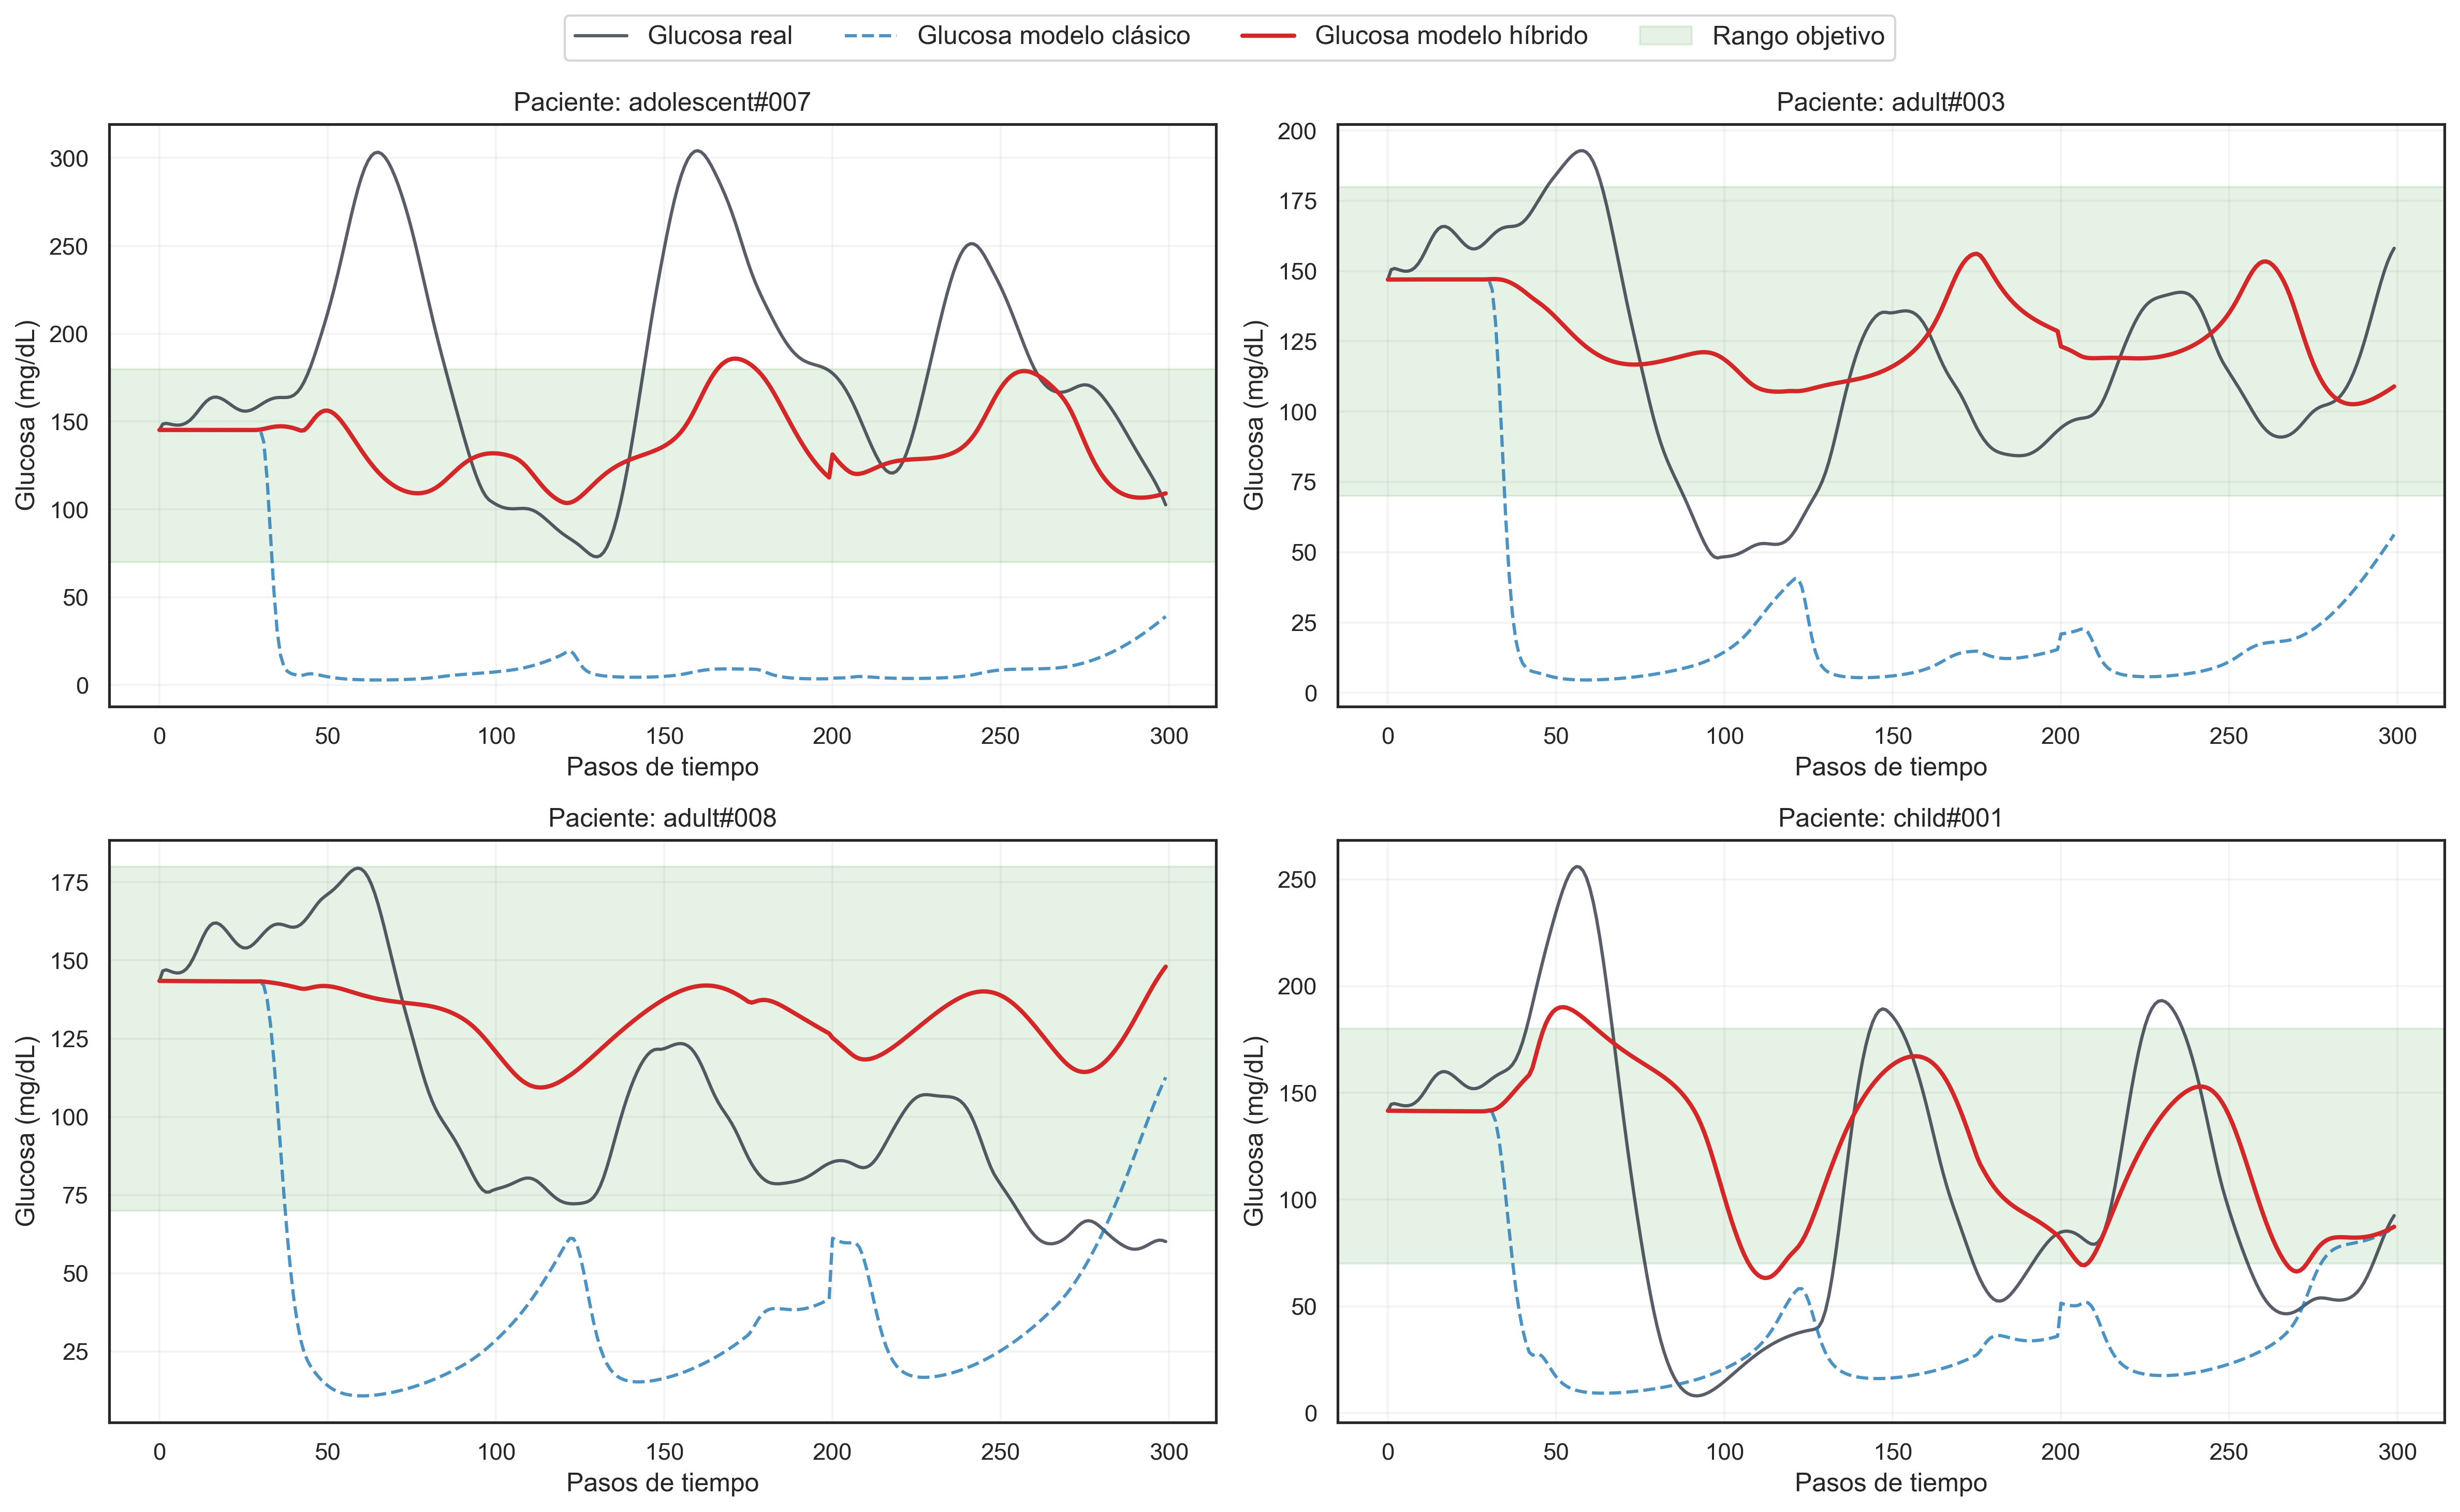

In [155]:
fig = plt.figure(figsize = (16, 10), dpi = 300)
L = 300

unique_pids = list(patients_joined.keys())[:4]

for i, p_id in enumerate(unique_pids):
    ax = plt.subplot(2, 2, i + 1)

    # Extraemos los valores
    y_real = np.array(patients_joined[p_id]["real_glucose"][:L])
    y_pred_hybrid = np.array(patients_joined[p_id]["pred_hybrid"][:L])
    y_pred_classic = np.array(patients_joined[p_id]["pred_classic"][:L])
    
    # Dibujamos las curvas
    ax.plot(y_real, color = colors["black"], label = "Glucosa real", linewidth = 1.5, alpha = 0.7)
    ax.plot(y_pred_classic, color = colors["blue"], label = "Glucosa modelo clásico", linewidth  =1.5, linestyle = "--", alpha = 0.8)
    ax.plot(y_pred_hybrid, color = colors["red"], label = "Glucosa modelo híbrido", linewidth = 2)
    
    # Graficamos una franja que delimita los valores de glucosa correctos para un paciente
    # Es decir, para asegurar que no entra en hipoglucemia o en hiperglucemia
    ax.axhspan(70, 180, color = "green", alpha = 0.1, label = "Rango objetivo")
    
    ax.set_title(f"Paciente: {p_id}", fontsize = 12)
    ax.set_ylabel("Glucosa (mg/dL)")
    ax.set_xlabel("Pasos de tiempo")
    ax.grid(True, alpha = 0.2)

# Colocamos la leyenda en la figura global
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc = "upper center", ncol = 4, fontsize = 12, bbox_to_anchor = (0.5, 0.98))

plt.tight_layout(rect = [0, 0, 1, 0.94])
plt.show()

#### 16.3.2. Curvas de aprendizaje

También graficamos las **curvas de pérdida en entrenamiento y validación**, para controlar que no existen signos de *overfitting*.

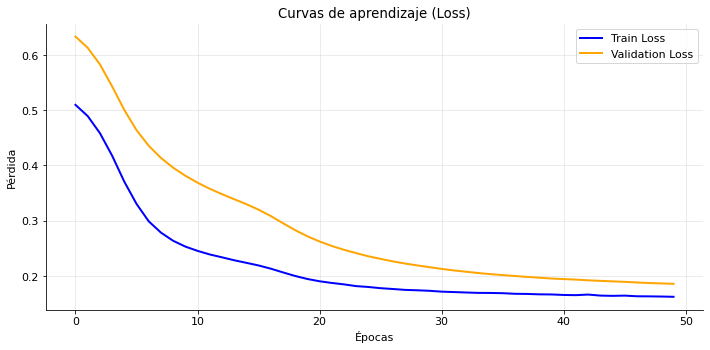

In [148]:
plt.figure(figsize = (10, 5))

# Dibujamos las curvas de loss
plt.plot(history_train_loss, label = "Train Loss", color = "blue", linewidth = 2)
plt.plot(history_val_loss, label = "Validation Loss", color = "orange", linewidth = 2)

plt.title("Curvas de aprendizaje (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")

# Ocultamos lineas superior y derecha
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.legend()
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

#### 16.3.3. Distribución de los errores

Realizamos una gráfica que permite visualizar la **distribución del error (RMSE) en todo el subconjunto de evaluación mediante el diagrama de violín**.

Además, incluye líneas que conectan el RMSE del enfoque clásico con el del enfoque híbrido por paciente. De esta forma, se puede visualizar cómo el modelo híbrido reduce el error en cada individuo, así como la magnitud de dicha mejora.

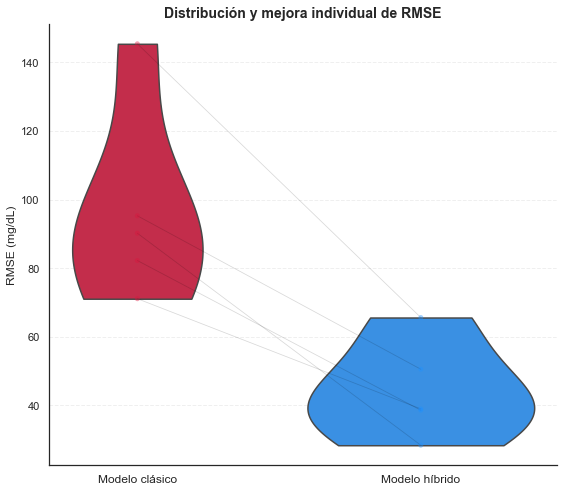

In [149]:
sns.set_theme(style = "white", palette = "muted")

df_melt = df_metrics.melt(id_vars = ["Paciente"], value_vars = ["RMSE_clasico", "RMSE_hibrido"], var_name = "Model", value_name = "RMSE")

# Creamos el grafico
plt.figure(figsize = (8, 7))
ax = plt.gca()

# Dibujamos el violin plot
sns.violinplot(data = df_melt, x = "Model", y = "RMSE", ax = ax, bw_adjust = 0.5, cut = 0, palette = ["crimson", "dodgerblue"], alpha = 0.3, inner = None)

# Dibujamos los puntos individuales
sns.stripplot(data = df_melt, x = "Model", y = "RMSE", ax = ax, size = 5, palette = ["crimson", "dodgerblue"], alpha = 0.4, jitter = False)

# Unimos los puntos
for patient_id in df_metrics["Paciente"]:
    p_data = df_metrics[df_metrics["Paciente"] == patient_id]
    classic_rmse = p_data["RMSE_clasico"].values[0]
    hybrid_rmse = p_data["RMSE_hibrido"].values[0]
    
    # Dibujamos la linea que conecta ambos modelos para el mismo paciente
    # 'Classic' es la posicion 0 y 'Hybrid' la 1
    ax.plot([0, 1], [classic_rmse, hybrid_rmse], color = "black", linestyle = "-", alpha = 0.15, linewidth = 0.8)


ax.set_title("Distribución y mejora individual de RMSE", fontsize = 14, fontweight = "bold")
ax.set_ylabel("RMSE (mg/dL)", fontsize = 12)
ax.set_xlabel("") 
ax.set_xticklabels(["Modelo clásico", "Modelo híbrido"], fontsize = 12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis = "y", linestyle = "--", alpha = 0.3)
plt.tight_layout()
plt.show()

#### 16.3.4. Error clínico - Análisis de rejilla de error de Clarke

Realizamos un **scatter plot que evalúa la exactitud global de las predicciones**.

En el presente trabajo, se ha establecido la Zona A, donde las predicciones se consideran muy precisas, y la Zona B, donde las predicciones se consideran aceptables a pesar de existir errores.

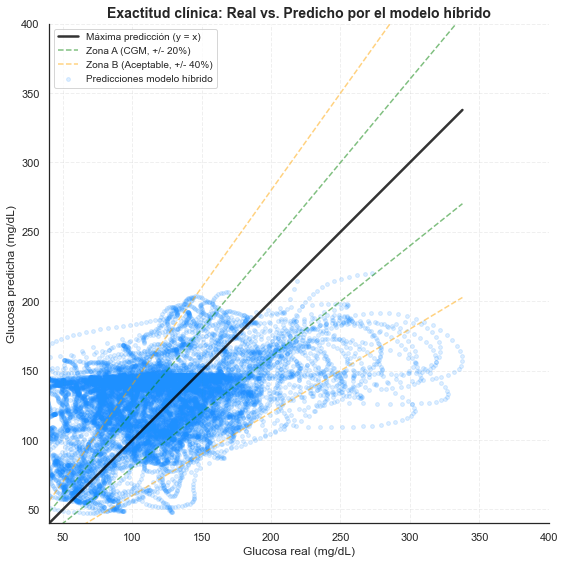

In [150]:
# Listas globales
y_true_all = np.array(all_real_glucose)
y_pred_all = np.array(all_pred_hybrid)

# Creacion del grafico
plt.figure(figsize=(9, 8))
ax = plt.gca()

# Dibujamos los puntos
ax.scatter(y_true_all, y_pred_all, color = "dodgerblue", alpha = 0.15, s = 15, label = "Predicciones modelo híbrido")

# Definimos limites realistas
limits = [max(y_true_all.min(), 40), min(y_true_all.max(), 400)] 
ax.plot(limits, limits, color = "black", linestyle = "-", alpha = 0.8, linewidth = 2.5, label = "Máxima predicción (y = x)")

# Zona A: errores de +/- 20% (clinicamente exactos en CGM)
ax.plot(limits, [lim * 1.2 for lim in limits], color = "green", linestyle = "--", alpha = 0.5, label = "Zona A (CGM, +/- 20%)")
ax.plot(limits, [lim * 0.8 for lim in limits], color = "green", linestyle = "--", alpha = 0.5)

# Zona B: errores aceptables que no llevan a malas decisiones clinicas (+/- 40%)
ax.plot(limits, [lim * 1.4 for lim in limits], color = "orange", linestyle = "--", alpha = 0.5, label = "Zona B (Aceptable, +/- 40%)")
ax.plot(limits, [lim * 0.6 for lim in limits], color = "orange", linestyle = "--", alpha = 0.5)

ax.set_title("Exactitud clínica: Real vs. Predicho por el modelo híbrido", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Glucosa real (mg/dL)", fontsize = 12)
ax.set_ylabel("Glucosa predicha (mg/dL)", fontsize = 12)

ax.set_xlim(40, 400)
ax.set_ylim(40, 400)
ax.set_aspect("equal") 

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle = "--", alpha = 0.3)
ax.legend(loc = "upper left", fontsize = 10)
plt.tight_layout()
plt.show()

Cuantificamos el porcentaje de predicciones que se encuentran en cada zona definida:

In [152]:
# Evitamos division por cero
epsilon = 1e-8

relative_error = np.abs(y_pred_all - y_true_all) / (y_true_all + epsilon)

zone_A = np.sum(relative_error <= 0.20)
zone_B = np.sum((relative_error > 0.20) & (relative_error <= 0.40))

total = len(y_true_all)

perc_A = 100 * zone_A / total
perc_A_B = 100 * (zone_A + zone_B) / total

print(f"% en ±20% (zona A aproximadamente): {perc_A:.2f}%")
print(f"% en ±40% (zona A+B aproximadamente): {perc_A_B:.2f}%")

% en ±20% (zona A aprox): 39.60%
% en ±40% (zona A+B aprox): 68.78%


#### 16.3.5. Distribución normal de residuos

Representa un **histograma de frecuencias de errores** entre la glucosa real y la glucosa predicha por el modelo híbrido, junto con una **estimación de densidad de kernel (KDE)**, que suaviza la forma real del histograma, y una **curva de distribución normal teórica (campana de Gauss)** ajustada a la media y desviación estándar de los errores.

De esta forma, se puede evaluar si el modelo tiende a sobrestimar o a subestimar la glucosa, dependiendo de la posición de la curva respecto del cero. Además, permite determinar si existen sesgos o patrones en los errores, dependiendo del ajuste de las barras del histograma dentro de la campana de Gauss.

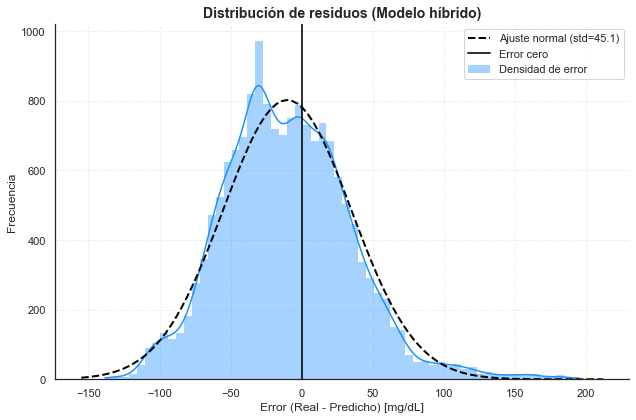

In [151]:
sns.set_theme(style = "white", palette = "muted")

# Calculamos los residuos globales
y_true_all = np.array(all_real_glucose)
y_pred_all = np.array(all_pred_hybrid)
residuals_all = y_true_all - y_pred_all

# Creamos la grafica
plt.figure(figsize = (9, 6))
ax = plt.gca()

# Dibujamos el histograma con KDE (densidad)
sns.histplot(residuals_all, kde = True, ax = ax, color = "dodgerblue", alpha = 0.4, bins = 60, label = "Densidad de error", linewidth = 0)

# Calculamos media y desviacion estadar para dibujar la campana teorica
mean_res, std_res = norm.fit(residuals_all)
xmin, xmax = ax.get_xlim()
x_norm = np.linspace(xmin, xmax, 100)
p_norm = norm.pdf(x_norm, mean_res, std_res)

# Ajustamos la escala para que la normal coincida con el histograma
scale_factor = len(residuals_all) * (residuals_all.max() - residuals_all.min()) / 60
ax.plot(x_norm, p_norm * scale_factor, color = "black", linewidth = 2, linestyle = "--", label = f"Ajuste normal (std={std_res:.1f})")

ax.set_title("Distribución de residuos (Modelo híbrido)", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Error (Real - Predicho) [mg/dL]", fontsize = 12)
ax.set_ylabel("Frecuencia", fontsize = 12)

# Linea en el error cero
ax.axvline(0, color = "black", linestyle = "-", alpha = 0.8, linewidth = 2, label = "Error cero") 

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle = "--", alpha = 0.3)
ax.legend()
plt.tight_layout()
plt.show()